# Importing data

data URL https://www.kaggle.com/datasets/bishals098/nasa-cmapss-2-engine-degradation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py


with h5py.File("../data/raw/N-CMAPSS_DS01-005.h5", "r") as f:
    print(f.keys())

<KeysViewHDF5 ['A_dev', 'A_test', 'A_var', 'T_dev', 'T_test', 'T_var', 'W_dev', 'W_test', 'W_var', 'X_s_dev', 'X_s_test', 'X_s_var', 'X_v_dev', 'X_v_test', 'X_v_var', 'Y_dev', 'Y_test']>


- to recognize we will split these name into suffix + the character :
- suffix : 
    - _dev ----> training data
    - _test ----> Testing data
    - _var ----> a small matrix holding the column names data
- litters : 
    - W ----> Operating conditions and settings
    - X_s ----> the real sensors reads
    - X_v ----> the virtual sensor reads
    - Y ----> Target
    - A ----> Auxiliary data and it usually having the unit number and Cycle
    - T ----> Health Parameters / Degradation Modifiers

### Create Training dataset : 
- > read all column names of [W, X_s, X_v, A, T] 
- > read all values of [W, X_s, X_v, A, T] 
- > convert each one to a single data frame
- > concate them in one data frame

In [2]:
# Create Training dataset
with h5py.File("../data/raw/N-CMAPSS_DS01-005.h5", "r") as f:
    W_var = f["W_var"][:]
    X_s_var = f["X_s_var"][:]
    X_v_var = f["X_v_var"][:]
    A_var = f["A_var"][:]
    T_var = f["T_var"][:]
    # no y because it is not a variable, but a label
    
    W_dev = f["W_dev"][:]
    X_s_dev = f["X_s_dev"][:]
    X_v_dev = f["X_v_dev"][:]
    A_dev = f["A_dev"][:]
    T_dev = f["T_dev"][:]
    Y_dev = f["Y_dev"][:]

# Decode bytes to strings for variable names    
W_var = [var.decode("utf-8") for var in W_var if isinstance(var, bytes)]
X_s_var = [var.decode("utf-8") for var in X_s_var if isinstance(var, bytes)]
X_v_var = [var.decode("utf-8") for var in X_v_var if isinstance(var, bytes)]
A_var = [var.decode("utf-8") for var in A_var if isinstance(var, bytes)]
T_var = [var.decode("utf-8") for var in T_var if isinstance(var, bytes)]


# Create a DataFrame for the training dataset
W_df = pd.DataFrame(W_dev, columns=W_var)
X_s_df = pd.DataFrame(X_s_dev, columns=X_s_var)
X_v_df = pd.DataFrame(X_v_dev, columns=X_v_var)
A_df = pd.DataFrame(A_dev, columns=A_var)
T_df = pd.DataFrame(T_dev, columns=T_var)
Y_df = pd.DataFrame(Y_dev, columns=["RUL"])

# concatenate all the DataFrames into a single DataFrame
train_df = pd.concat([W_df, X_s_df, X_v_df, A_df, T_df, Y_df], axis=1)

In [3]:
train_df.shape

(4906636, 47)

In [4]:
train_df.columns

Index(['alt', 'Mach', 'TRA', 'T2', 'T24', 'T30', 'T48', 'T50', 'P15', 'P2',
       'P21', 'P24', 'Ps30', 'P40', 'P50', 'Nf', 'Nc', 'Wf', 'T40', 'P30',
       'P45', 'W21', 'W22', 'W25', 'W31', 'W32', 'W48', 'W50', 'SmFan',
       'SmLPC', 'SmHPC', 'phi', 'unit', 'cycle', 'Fc', 'hs', 'fan_eff_mod',
       'fan_flow_mod', 'LPC_eff_mod', 'LPC_flow_mod', 'HPC_eff_mod',
       'HPC_flow_mod', 'HPT_eff_mod', 'HPT_flow_mod', 'LPT_eff_mod',
       'LPT_flow_mod', 'RUL'],
      dtype='str')

In [5]:
train_df.head()

,alt,Mach,TRA,T2,T24,T30,T48,T50,P15,P2,...,fan_flow_mod,LPC_eff_mod,LPC_flow_mod,HPC_eff_mod,HPC_flow_mod,HPT_eff_mod,HPT_flow_mod,LPT_eff_mod,LPT_flow_mod,RUL
0,3013.0,0.376362,70.311996,522.314770,618.288596,1470.469798,1849.620676,1269.275585,19.432070,14.484611,...,0.0,0.0,0.0,0.0,0.0,-0.000604,0.0,0.0,0.0,99
1,3020.0,0.376866,70.311996,522.327145,618.296355,1470.415593,1849.519871,1269.177159,19.431385,14.484683,...,0.0,0.0,0.0,0.0,0.0,-0.000604,0.0,0.0,0.0,99
2,3025.0,0.377685,70.311996,522.371840,618.336514,1470.453853,1849.566139,1269.167353,19.435163,14.488224,...,0.0,0.0,0.0,0.0,0.0,-0.000604,0.0,0.0,0.0,99
3,3035.0,0.376992,70.399887,522.282418,618.302173,1470.650929,1850.195069,1269.518670,19.426003,14.477632,...,0.0,0.0,0.0,0.0,0.0,-0.000604,0.0,0.0,0.0,99
4,3043.0,0.377622,70.399887,522.300605,618.345228,1470.640421,1849.950988,1269.253972,19.427484,14.478114,...,0.0,0.0,0.0,0.0,0.0,-0.000604,0.0,0.0,0.0,99


There is a Dead column (It have only 0) we will delete it

In [6]:
zero_columns = ["fan_eff_mod", "fan_flow_mod", "LPC_eff_mod", "LPC_flow_mod", "HPC_eff_mod", "HPC_flow_mod", "HPT_flow_mod", "LPT_flow_mod", "LPT_eff_mod"]

train_df.drop(columns=zero_columns, inplace=True)

In [7]:
train_df["RUL"].unique() 

array([99, 98, 97, 96, 95, 94, 93, 92, 91, 90, 89, 88, 87, 86, 85, 84, 83,
       82, 81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66,
       65, 64, 63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49,
       48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32,
       31, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15,
       14, 13, 12, 11, 10,  9,  8,  7,  6,  5,  4,  3,  2,  1,  0])

In [8]:
train_df["hs"].unique()

array([1., 0.])

In [9]:
train_df.head()

,alt,Mach,TRA,T2,T24,T30,T48,T50,P15,P2,...,SmFan,SmLPC,SmHPC,phi,unit,cycle,Fc,hs,HPT_eff_mod,RUL
0,3013.0,0.376362,70.311996,522.314770,618.288596,1470.469798,1849.620676,1269.275585,19.432070,14.484611,...,15.879671,9.925145,25.648148,42.152925,1.0,1.0,1.0,1.0,-0.000604,99
1,3020.0,0.376866,70.311996,522.327145,618.296355,1470.415593,1849.519871,1269.177159,19.431385,14.484683,...,15.888485,9.916771,25.651719,42.150936,1.0,1.0,1.0,1.0,-0.000604,99
2,3025.0,0.377685,70.311996,522.371840,618.336514,1470.453853,1849.566139,1269.167353,19.435163,14.488224,...,15.902505,9.911186,25.652633,42.151475,1.0,1.0,1.0,1.0,-0.000604,99
3,3035.0,0.376992,70.399887,522.282418,618.302173,1470.650929,1850.195069,1269.518670,19.426003,14.477632,...,15.889568,9.927131,25.632641,42.169738,1.0,1.0,1.0,1.0,-0.000604,99
4,3043.0,0.377622,70.399887,522.300605,618.345228,1470.640421,1849.950988,1269.253972,19.427484,14.478114,...,15.895957,9.916870,25.644562,42.160144,1.0,1.0,1.0,1.0,-0.000604,99


In [10]:
train_df["cycle"].unique()

array([  1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
        12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
        23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
        45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,
        56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,
        67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,
        78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,
        89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99.,
       100.])

In [11]:
train_df.columns

Index(['alt', 'Mach', 'TRA', 'T2', 'T24', 'T30', 'T48', 'T50', 'P15', 'P2',
       'P21', 'P24', 'Ps30', 'P40', 'P50', 'Nf', 'Nc', 'Wf', 'T40', 'P30',
       'P45', 'W21', 'W22', 'W25', 'W31', 'W32', 'W48', 'W50', 'SmFan',
       'SmLPC', 'SmHPC', 'phi', 'unit', 'cycle', 'Fc', 'hs', 'HPT_eff_mod',
       'RUL'],
      dtype='str')

In [12]:
train_df.isna().sum()

alt            0
Mach           0
TRA            0
T2             0
T24            0
T30            0
T48            0
T50            0
P15            0
P2             0
P21            0
P24            0
Ps30           0
P40            0
P50            0
Nf             0
Nc             0
Wf             0
T40            0
P30            0
P45            0
W21            0
W22            0
W25            0
W31            0
W32            0
W48            0
W50            0
SmFan          0
SmLPC          0
SmHPC          0
phi            0
unit           0
cycle          0
Fc             0
hs             0
HPT_eff_mod    0
RUL            0
dtype: int64

the NULL Values is 0 for all columns (No Null Values)

In [13]:
train_df.duplicated().sum()

np.int64(0)

In [14]:
train_df["unit"].unique()

array([1., 2., 3., 4., 5., 6.])

In [15]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4906636 entries, 0 to 4906635
Data columns (total 38 columns):
 #   Column       Dtype  
---  ------       -----  
 0   alt          float64
 1   Mach         float64
 2   TRA          float64
 3   T2           float64
 4   T24          float64
 5   T30          float64
 6   T48          float64
 7   T50          float64
 8   P15          float64
 9   P2           float64
 10  P21          float64
 11  P24          float64
 12  Ps30         float64
 13  P40          float64
 14  P50          float64
 15  Nf           float64
 16  Nc           float64
 17  Wf           float64
 18  T40          float64
 19  P30          float64
 20  P45          float64
 21  W21          float64
 22  W22          float64
 23  W25          float64
 24  W31          float64
 25  W32          float64
 26  W48          float64
 27  W50          float64
 28  SmFan        float64
 29  SmLPC        float64
 30  SmHPC        float64
 31  phi          float64
 32  unit     

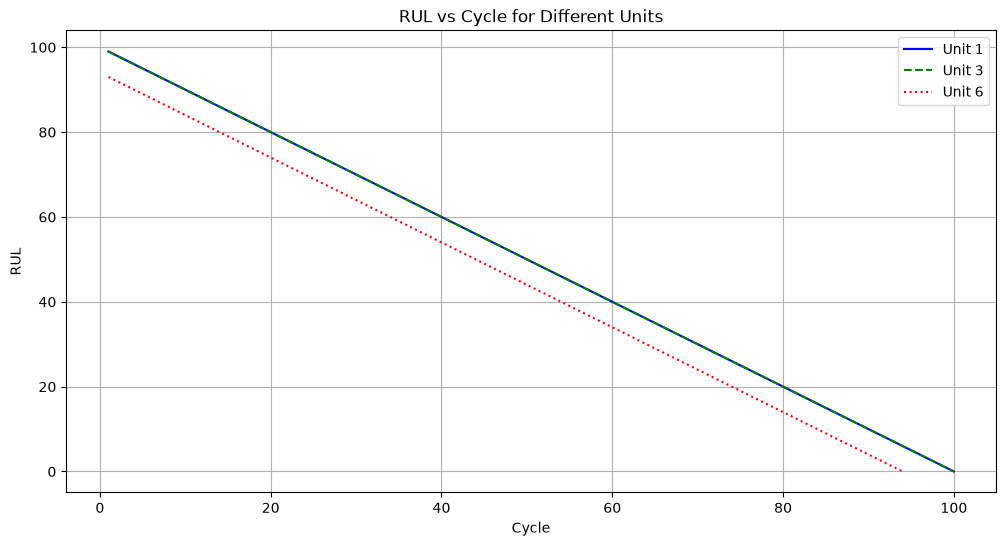

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(train_df.loc[train_df["unit"] == 1, "cycle"], train_df.loc[train_df["unit"] == 1, "RUL"], linestyle='-', color='blue', label='Unit 1')
plt.plot(train_df.loc[train_df["unit"] == 3, "cycle"], train_df.loc[train_df["unit"] == 3, "RUL"], linestyle='--', color='green', label='Unit 3')
plt.plot(train_df.loc[train_df["unit"] == 6, "cycle"], train_df.loc[train_df["unit"] == 6, "RUL"], linestyle=':', color='red', label='Unit 6')
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title("RUL vs Cycle for Different Units")
plt.legend()

plt.grid()
plt.savefig("../docs/figs/RUL_vs_Cycle_for_Different_Units.png", bbox_inches='tight')
plt.show()

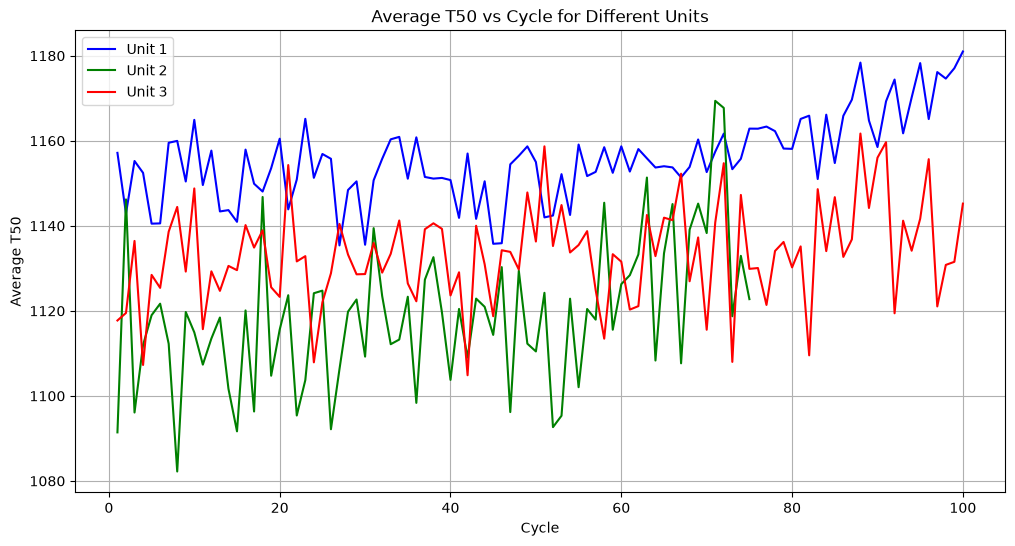

In [17]:
df_grouped1 = train_df[train_df["unit"] == 1].groupby("cycle")["T50"].mean().reset_index()
df_grouped2 = train_df[train_df["unit"] == 2].groupby("cycle")["T50"].mean().reset_index()
df_grouped3 = train_df[train_df["unit"] == 3].groupby("cycle")["T50"].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(df_grouped1["cycle"], df_grouped1["T50"], linestyle='-', color='blue', label='Unit 1')
plt.plot(df_grouped2["cycle"], df_grouped2["T50"], linestyle='-', color='green', label='Unit 2')
plt.plot(df_grouped3["cycle"], df_grouped3["T50"], linestyle='-', color='red', label='Unit 3')
plt.xlabel("Cycle")
plt.ylabel("Average T50")
plt.title("Average T50 vs Cycle for Different Units")
plt.grid()
plt.legend()
plt.savefig("../docs/figs/Average_T50_vs_Cycle_for_Different_Units.png", bbox_inches='tight')
plt.show()

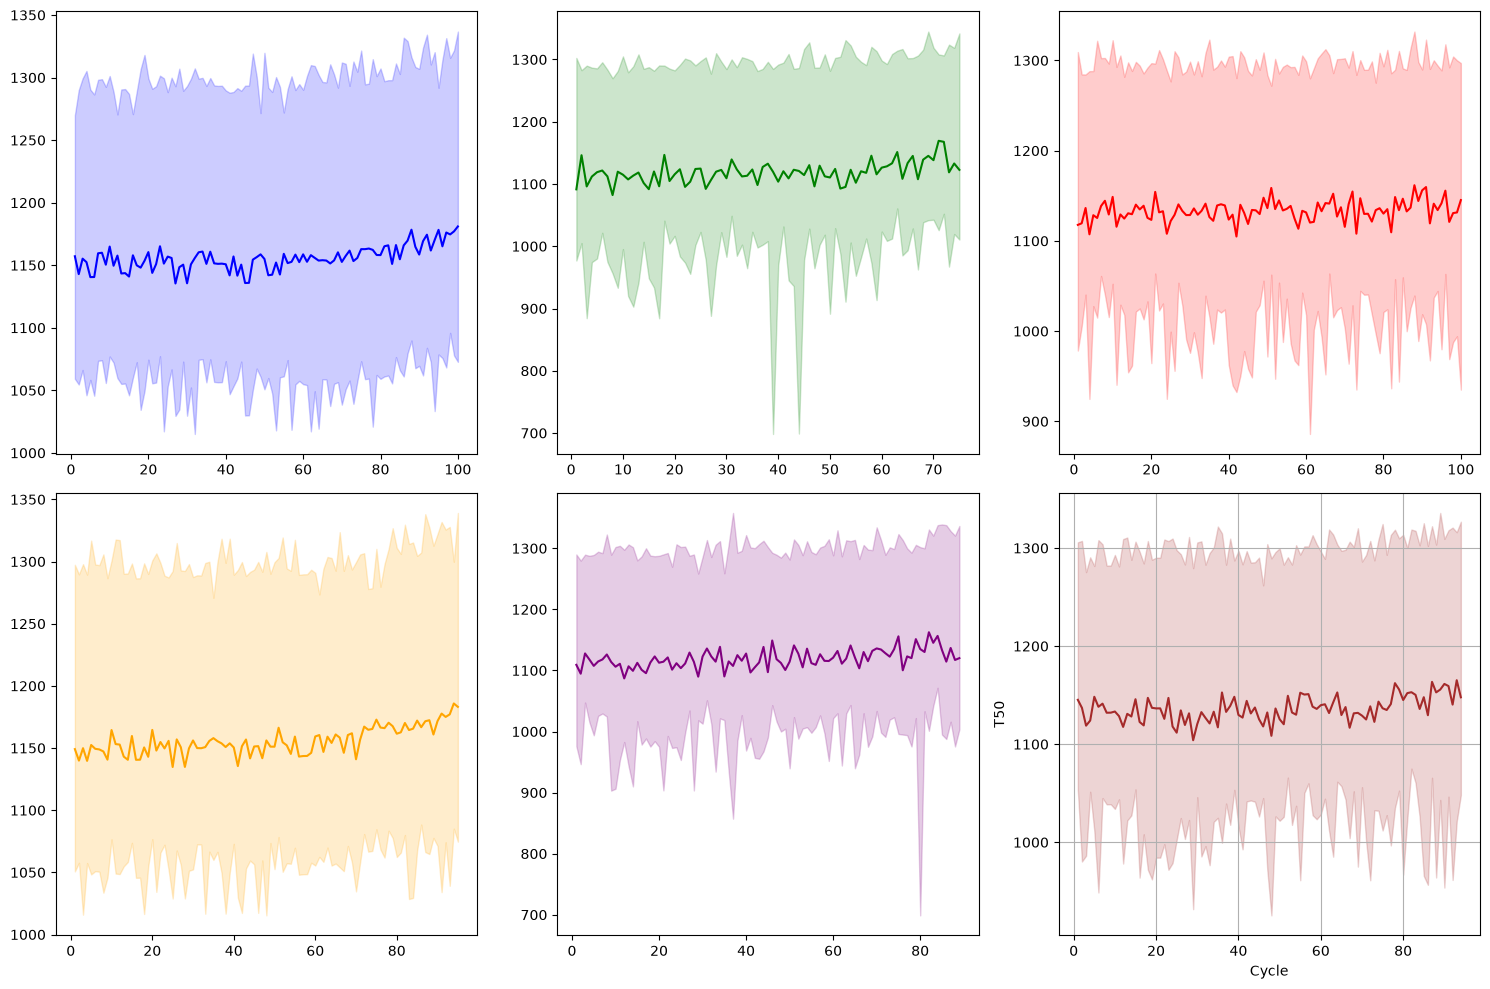

In [18]:
stats1 = train_df[train_df["unit"] == 1].groupby("cycle")["T50"].agg(["mean", "min", "max"]).reset_index()
stats2 = train_df[train_df["unit"] == 2].groupby("cycle")["T50"].agg(["mean", "min", "max"]).reset_index()
stats3 = train_df[train_df["unit"] == 3].groupby("cycle")["T50"].agg(["mean", "min", "max"]).reset_index()
stats4 = train_df[train_df["unit"] == 4].groupby("cycle")["T50"].agg(["mean", "min", "max"]).reset_index()
stats5 = train_df[train_df["unit"] == 5].groupby("cycle")["T50"].agg(["mean", "min", "max"]).reset_index()
stats6 = train_df[train_df["unit"] == 6].groupby("cycle")["T50"].agg(["mean", "min", "max"]).reset_index()


fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0, 0].plot(stats1["cycle"], stats1["mean"], color="blue", label="Mean T50 for Unit 1")
axs[0, 0].fill_between(stats1["cycle"], stats1["min"], stats1["max"], color="blue", alpha=0.2, label="Min-Max Range for Unit 1")

axs[0, 1].plot(stats2["cycle"], stats2["mean"], color="green", label="Mean T50 for Unit 2")
axs[0, 1].fill_between(stats2["cycle"], stats2["min"], stats2["max"], color="green", alpha=0.2, label="Min-Max Range for Unit 2")

axs[0, 2].plot(stats3["cycle"], stats3["mean"], color="red", label="Mean T50 for Unit 3")
axs[0, 2].fill_between(stats3["cycle"], stats3["min"], stats3["max"], color="red", alpha=0.2, label="Min-Max Range for Unit 3")

axs[1, 0].plot(stats4["cycle"], stats4["mean"], color="orange", label="Mean T50 for Unit 4")
axs[1, 0].fill_between(stats4["cycle"], stats4["min"], stats4["max"], color="orange", alpha=0.2, label="Min-Max Range for Unit 4")

axs[1, 1].plot(stats5["cycle"], stats5["mean"], color="purple", label="Mean T50 for Unit 5")
axs[1, 1].fill_between(stats5["cycle"], stats5["min"], stats5["max"], color="purple", alpha=0.2, label="Min-Max Range for Unit 5")

axs[1, 2].plot(stats6["cycle"], stats6["mean"], color="brown", label="Mean T50 for Unit 6")
axs[1, 2].fill_between(stats6["cycle"], stats6["min"], stats6["max"], color="brown", alpha=0.2, label="Min-Max Range for Unit 6")


plt.xlabel("Cycle")
plt.ylabel("T50")
plt.tight_layout()
plt.grid()
plt.savefig("../docs/figs/Average_T50_vs_Cycle_for_Different_Units_with_Ranges.png", bbox_inches='tight')
plt.show()

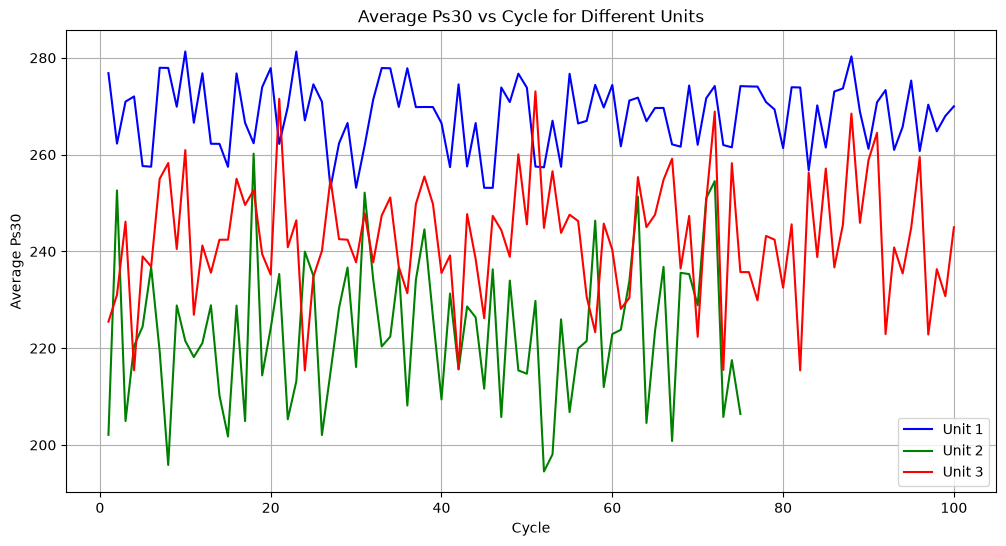

In [19]:
df_grouped1 = train_df[train_df["unit"] == 1].groupby("cycle")["Ps30"].mean().reset_index()
df_grouped2 = train_df[train_df["unit"] == 2].groupby("cycle")["Ps30"].mean().reset_index()
df_grouped3 = train_df[train_df["unit"] == 3].groupby("cycle")["Ps30"].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(df_grouped1["cycle"], df_grouped1["Ps30"], linestyle='-', color='blue', label='Unit 1')
plt.plot(df_grouped2["cycle"], df_grouped2["Ps30"], linestyle='-', color='green', label='Unit 2')
plt.plot(df_grouped3["cycle"], df_grouped3["Ps30"], linestyle='-', color='red', label='Unit 3')
plt.xlabel("Cycle")
plt.ylabel("Average Ps30")
plt.title("Average Ps30 vs Cycle for Different Units")
plt.grid()
plt.legend()
plt.savefig("../docs/figs/Average_Ps30_vs_Cycle_for_Different_Units.png", bbox_inches='tight')
plt.show()

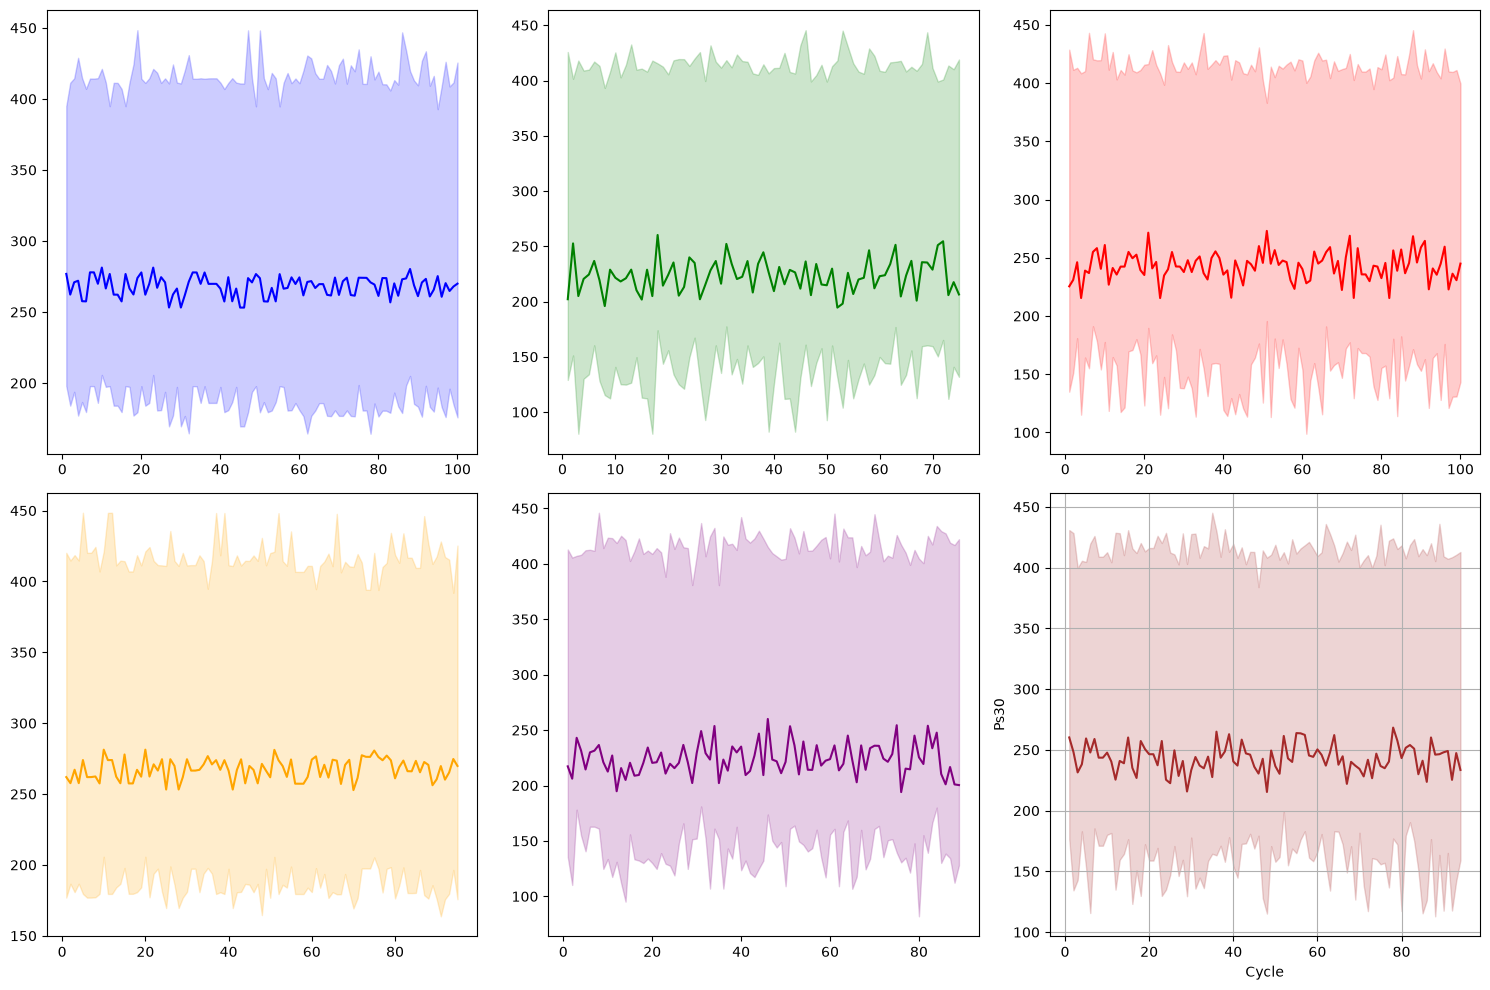

In [20]:
stats1 = train_df[train_df["unit"] == 1].groupby("cycle")["Ps30"].agg(["mean", "min", "max"]).reset_index()
stats2 = train_df[train_df["unit"] == 2].groupby("cycle")["Ps30"].agg(["mean", "min", "max"]).reset_index()
stats3 = train_df[train_df["unit"] == 3].groupby("cycle")["Ps30"].agg(["mean", "min", "max"]).reset_index()
stats4 = train_df[train_df["unit"] == 4].groupby("cycle")["Ps30"].agg(["mean", "min", "max"]).reset_index()
stats5 = train_df[train_df["unit"] == 5].groupby("cycle")["Ps30"].agg(["mean", "min", "max"]).reset_index()
stats6 = train_df[train_df["unit"] == 6].groupby("cycle")["Ps30"].agg(["mean", "min", "max"]).reset_index()


fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0, 0].plot(stats1["cycle"], stats1["mean"], color="blue", label="Mean Ps30 for Unit 1")
axs[0, 0].fill_between(stats1["cycle"], stats1["min"], stats1["max"], color="blue", alpha=0.2, label="Min-Max Range for Unit 1")

axs[0, 1].plot(stats2["cycle"], stats2["mean"], color="green", label="Mean Ps30 for Unit 2")
axs[0, 1].fill_between(stats2["cycle"], stats2["min"], stats2["max"], color="green", alpha=0.2, label="Min-Max Range for Unit 2")

axs[0, 2].plot(stats3["cycle"], stats3["mean"], color="red", label="Mean Ps30 for Unit 3")
axs[0, 2].fill_between(stats3["cycle"], stats3["min"], stats3["max"], color="red", alpha=0.2, label="Min-Max Range for Unit 3")

axs[1, 0].plot(stats4["cycle"], stats4["mean"], color="orange", label="Mean Ps30 for Unit 4")
axs[1, 0].fill_between(stats4["cycle"], stats4["min"], stats4["max"], color="orange", alpha=0.2, label="Min-Max Range for Unit 4")

axs[1, 1].plot(stats5["cycle"], stats5["mean"], color="purple", label="Mean Ps30 for Unit 5")
axs[1, 1].fill_between(stats5["cycle"], stats5["min"], stats5["max"], color="purple", alpha=0.2, label="Min-Max Range for Unit 5")

axs[1, 2].plot(stats6["cycle"], stats6["mean"], color="brown", label="Mean Ps30 for Unit 6")
axs[1, 2].fill_between(stats6["cycle"], stats6["min"], stats6["max"], color="brown", alpha=0.2, label="Min-Max Range for Unit 6")


plt.xlabel("Cycle")
plt.ylabel("Ps30")
plt.tight_layout()
plt.grid()
plt.savefig("../docs/figs/Average_Ps30_vs_Cycle_for_Different_Units_with_Ranges.png", bbox_inches='tight')
plt.show()

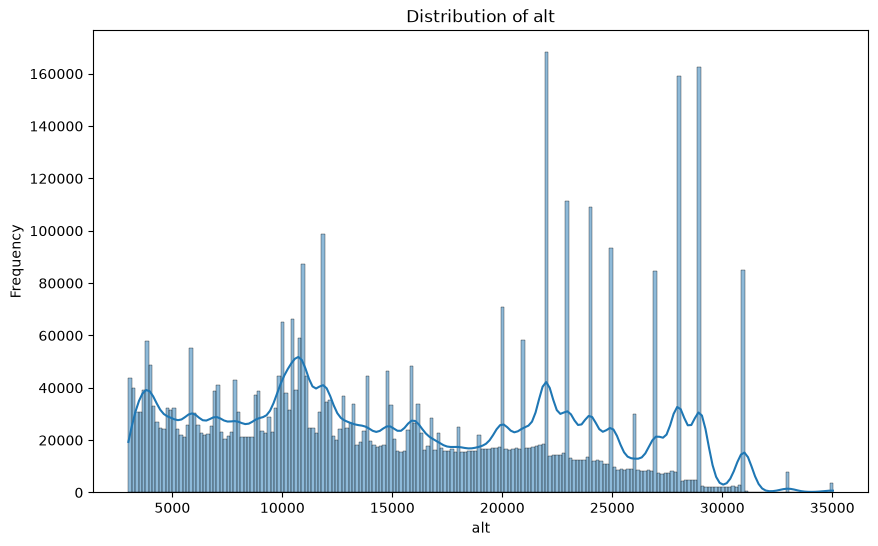

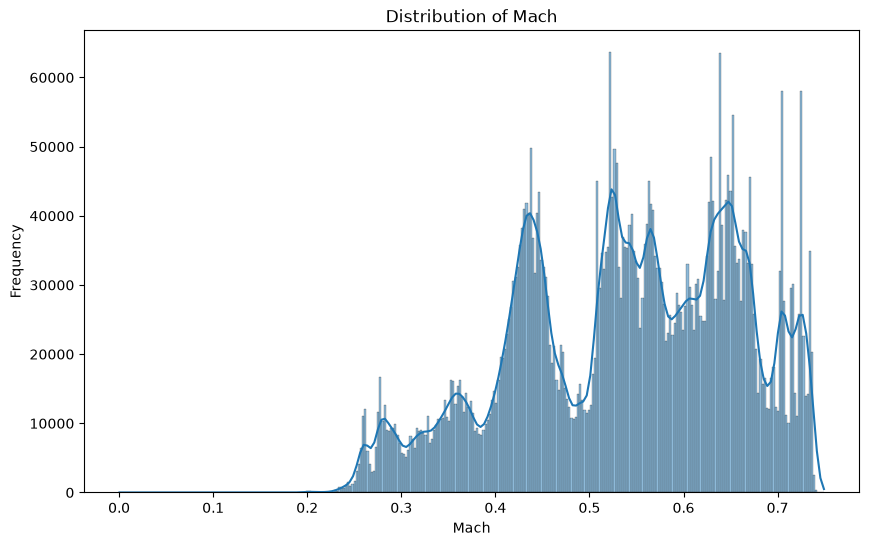

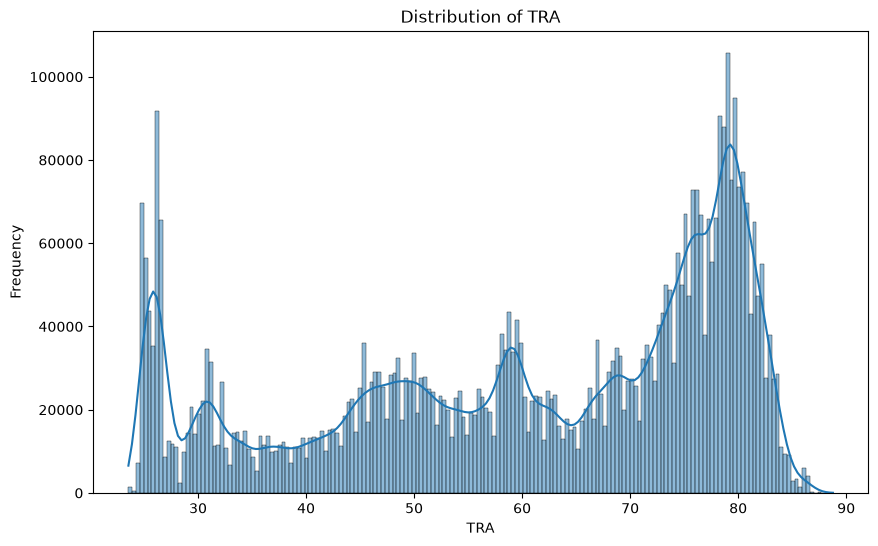

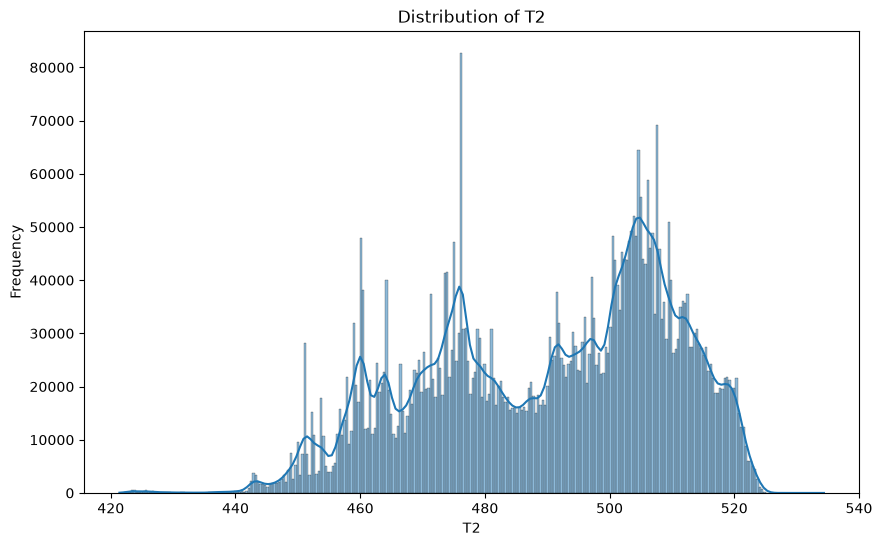

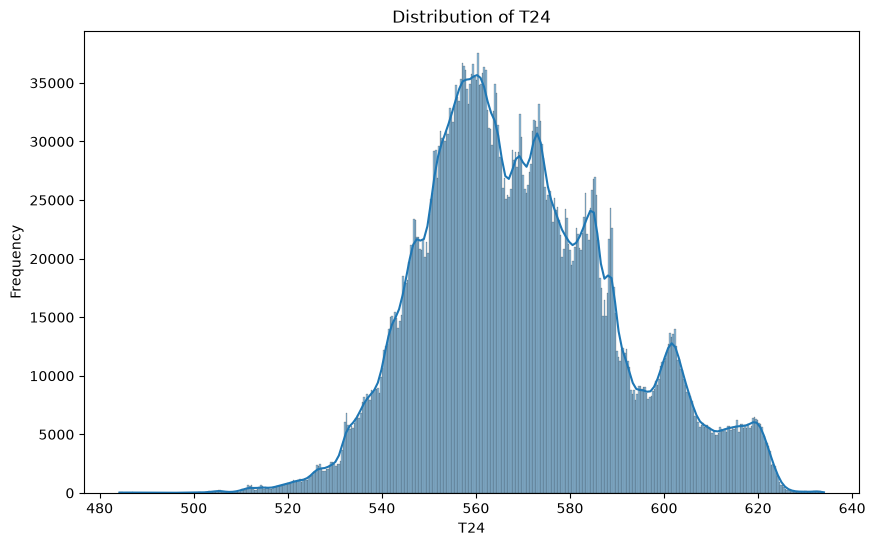

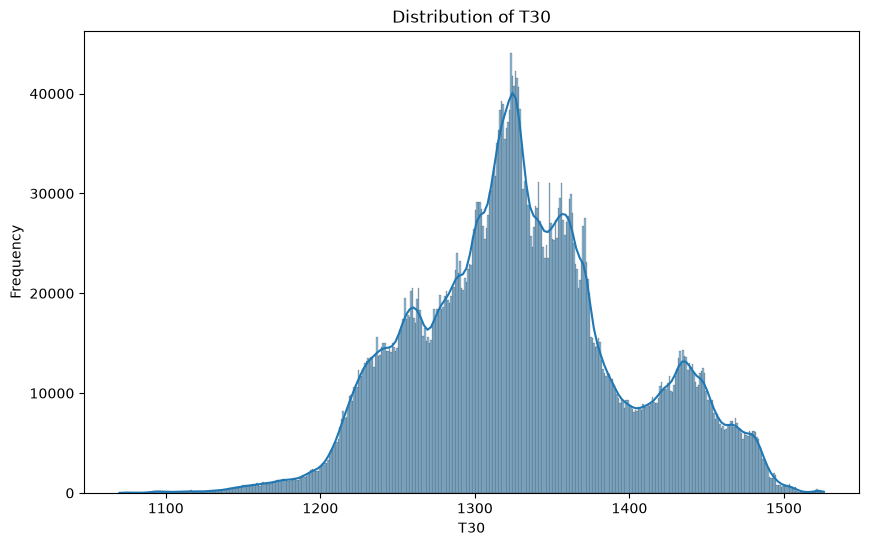

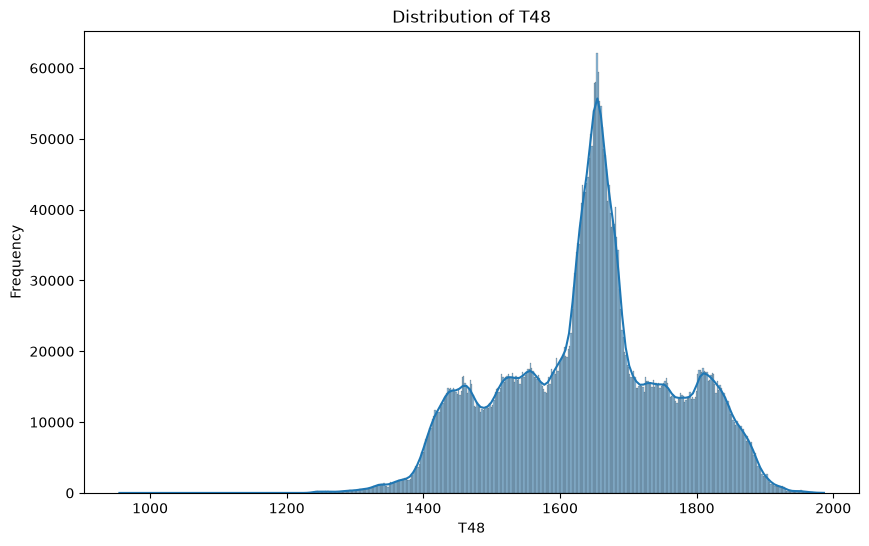

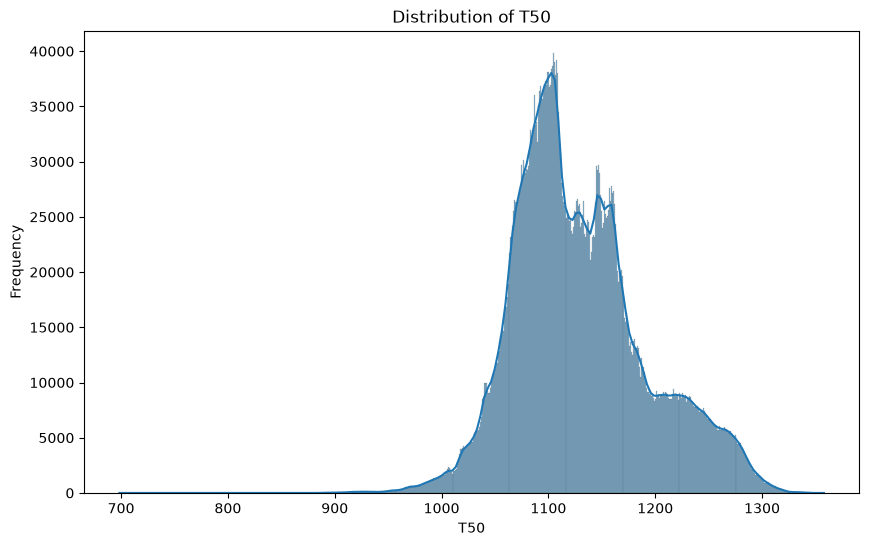

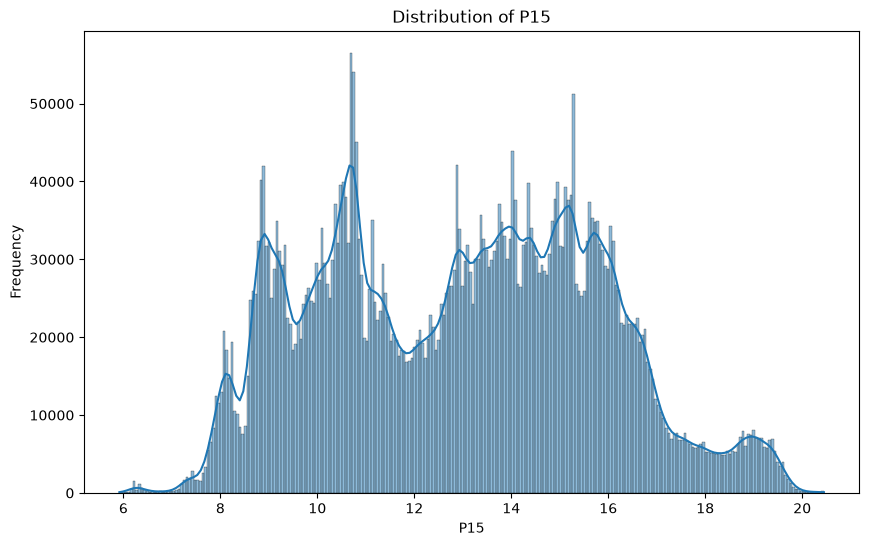

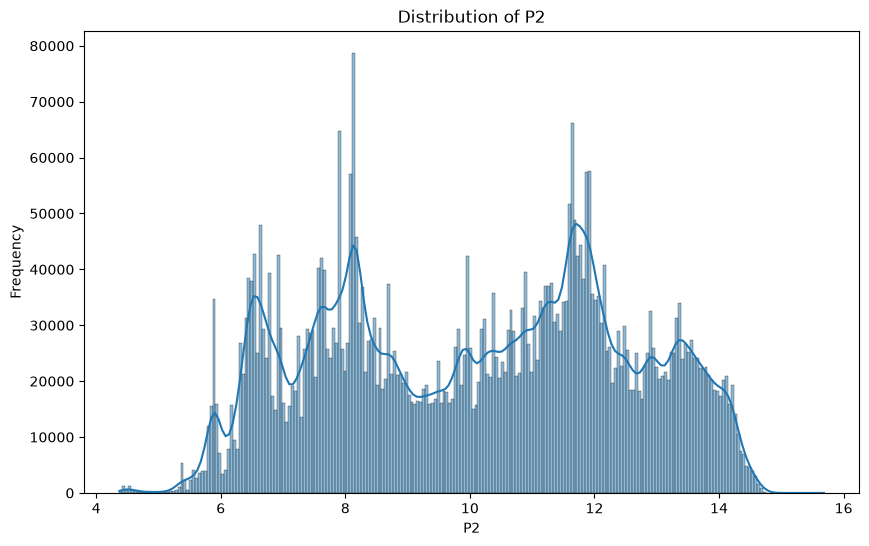

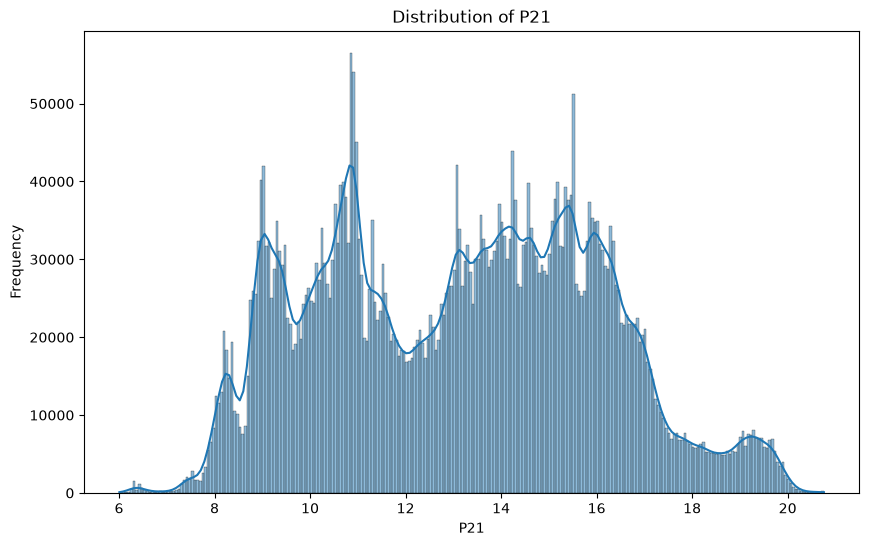

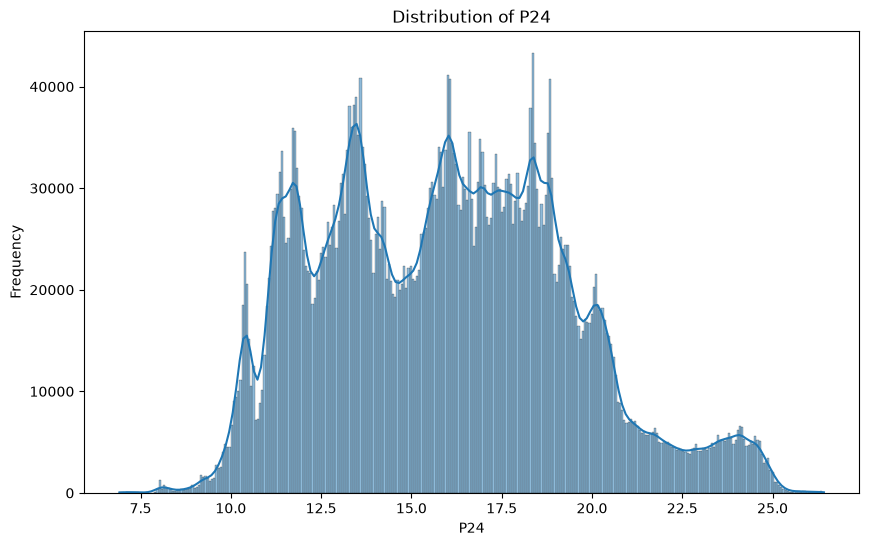

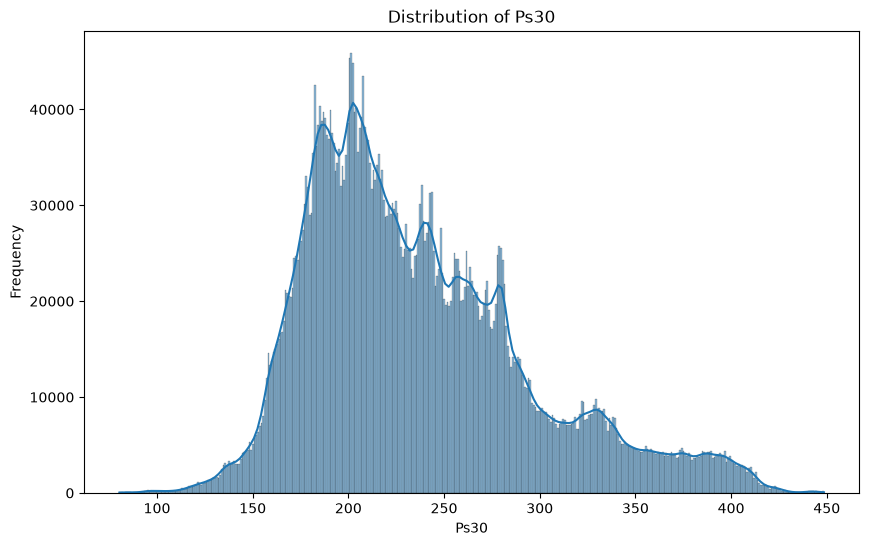

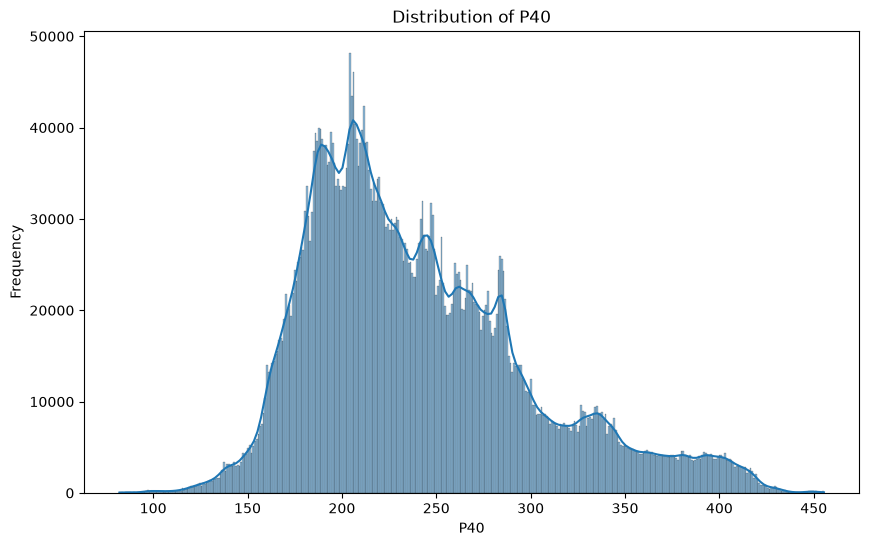

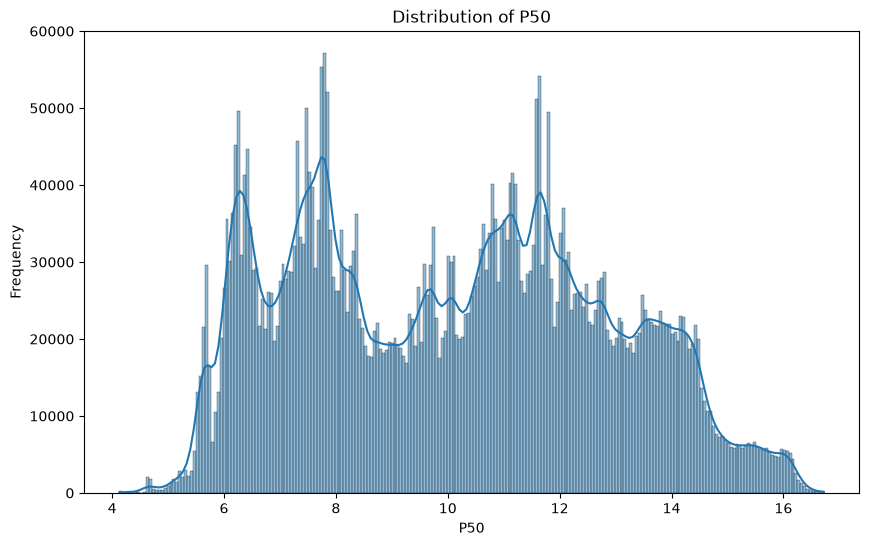

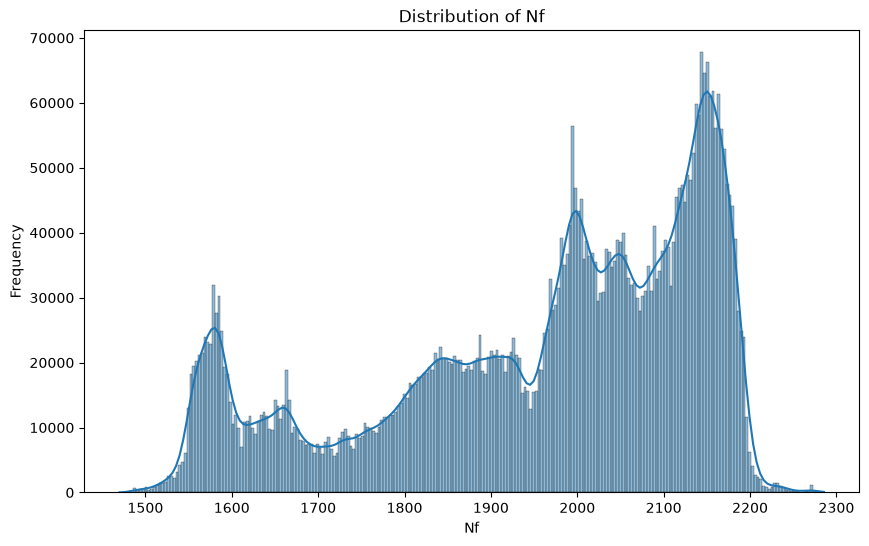

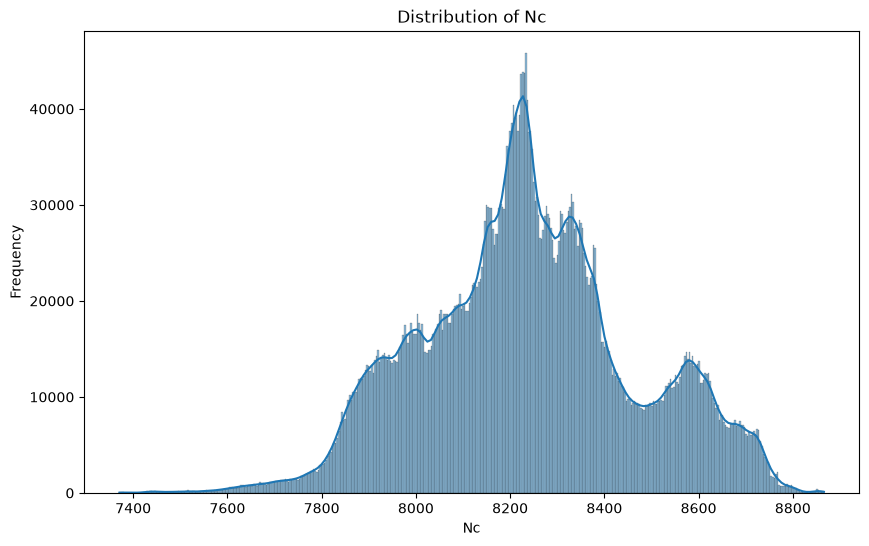

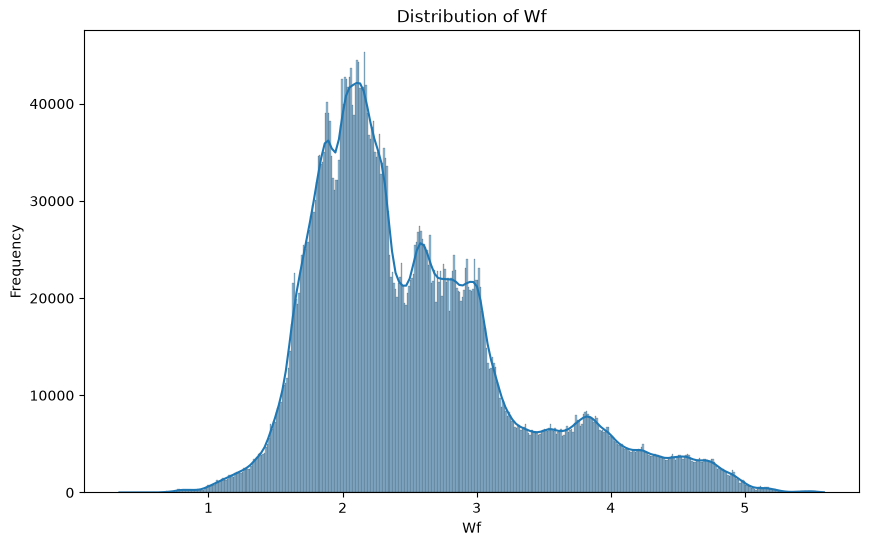

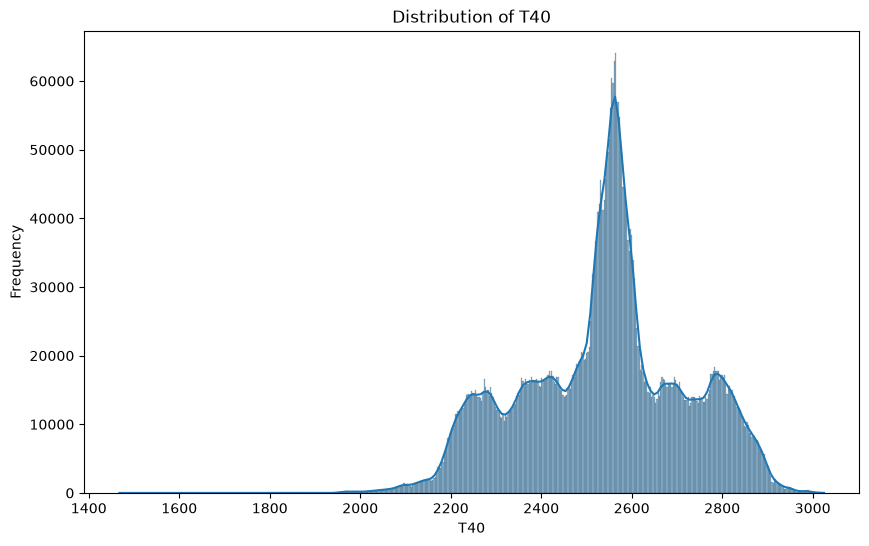

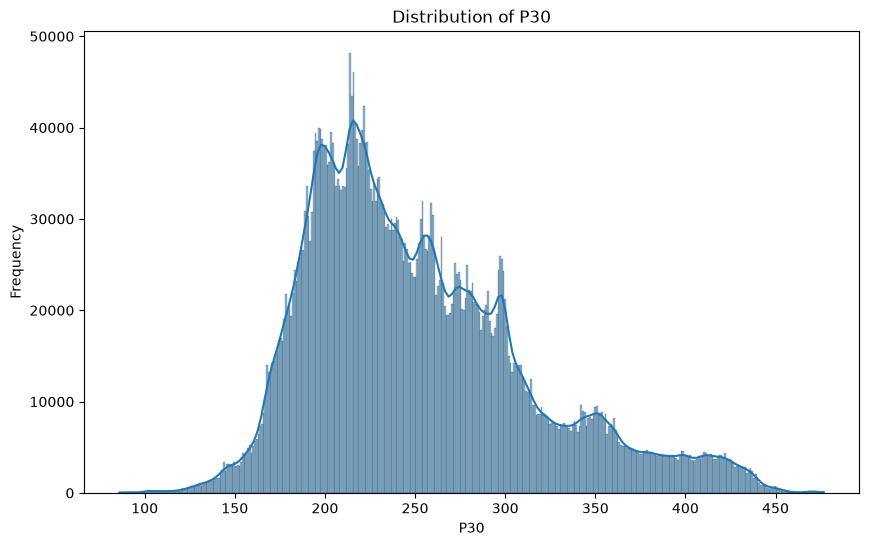

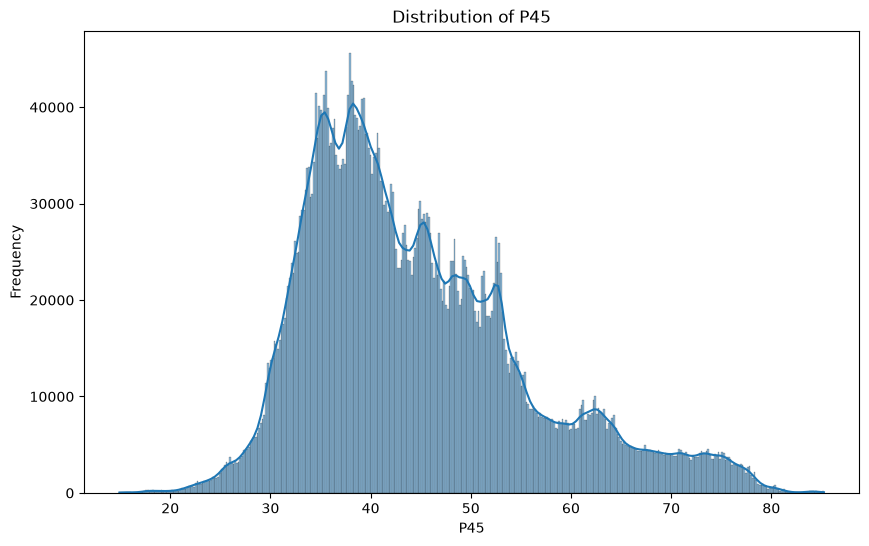

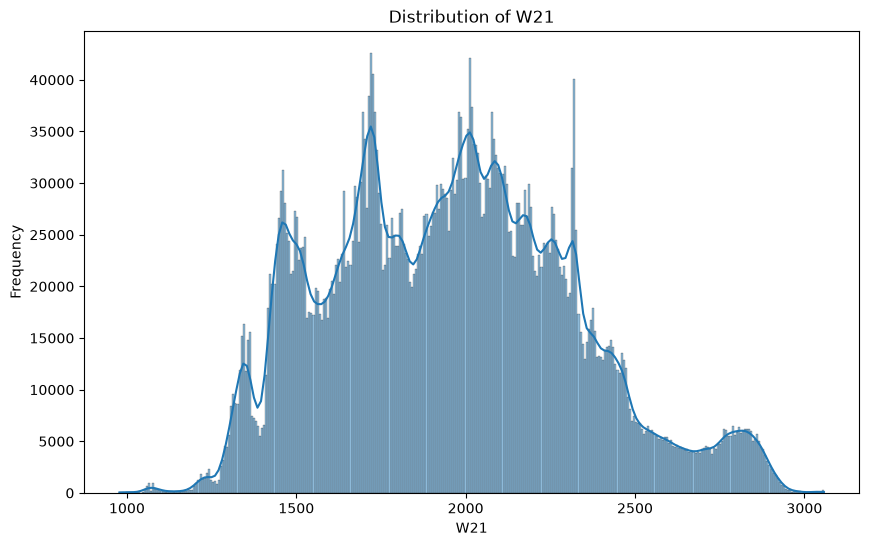

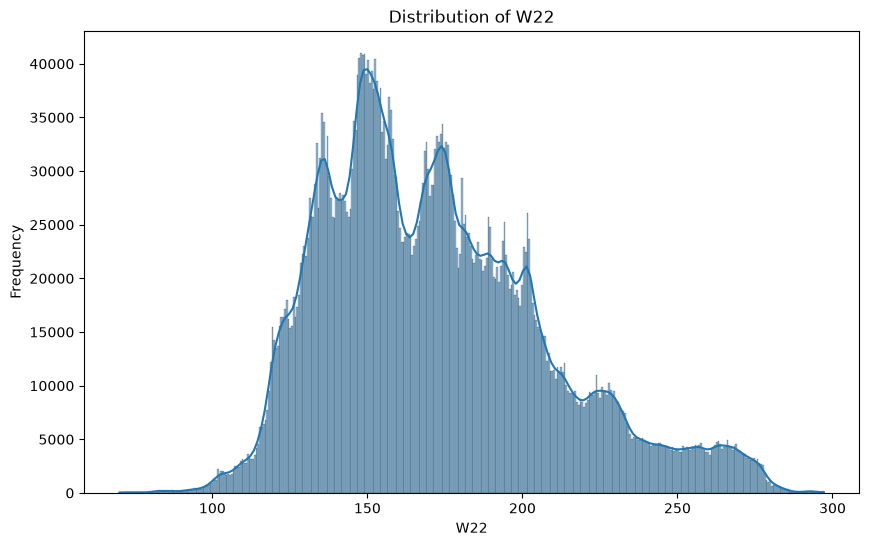

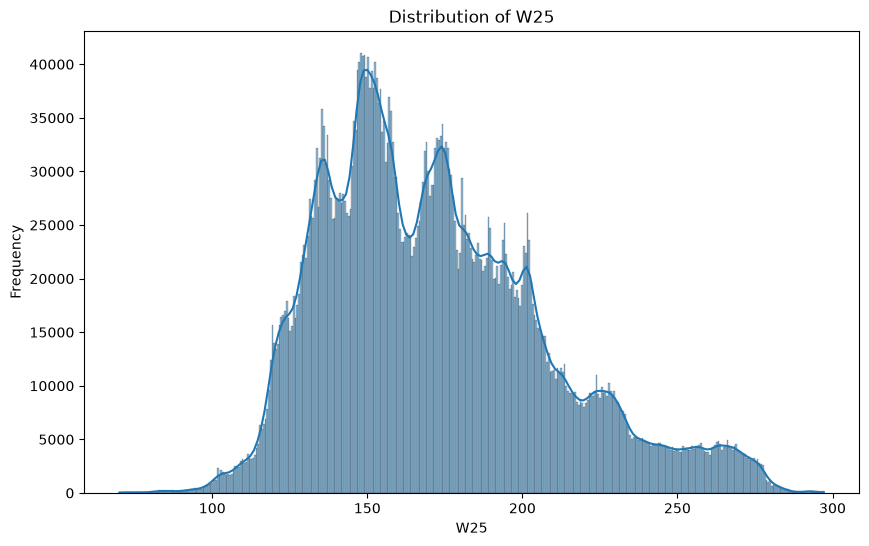

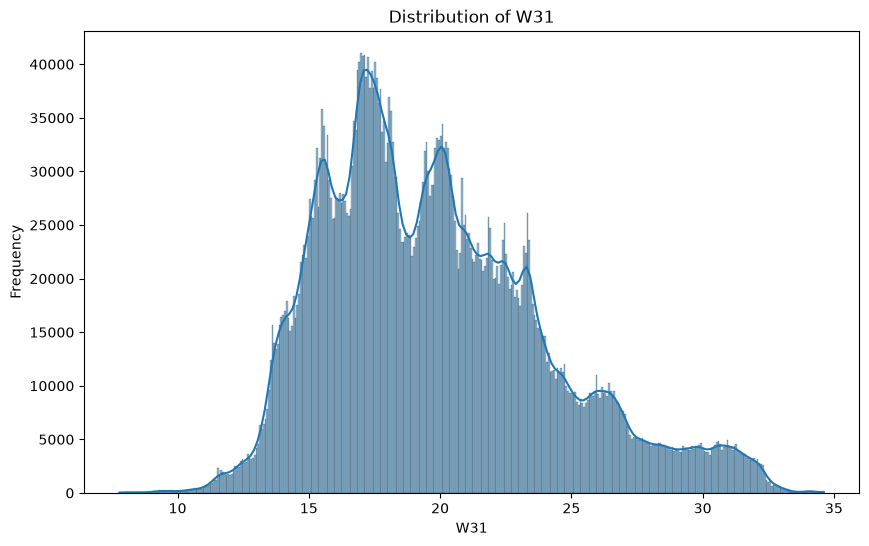

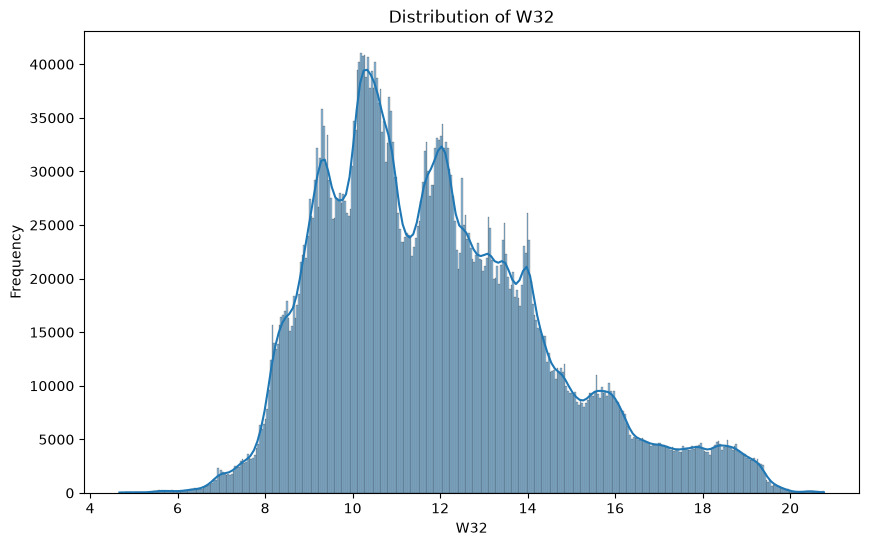

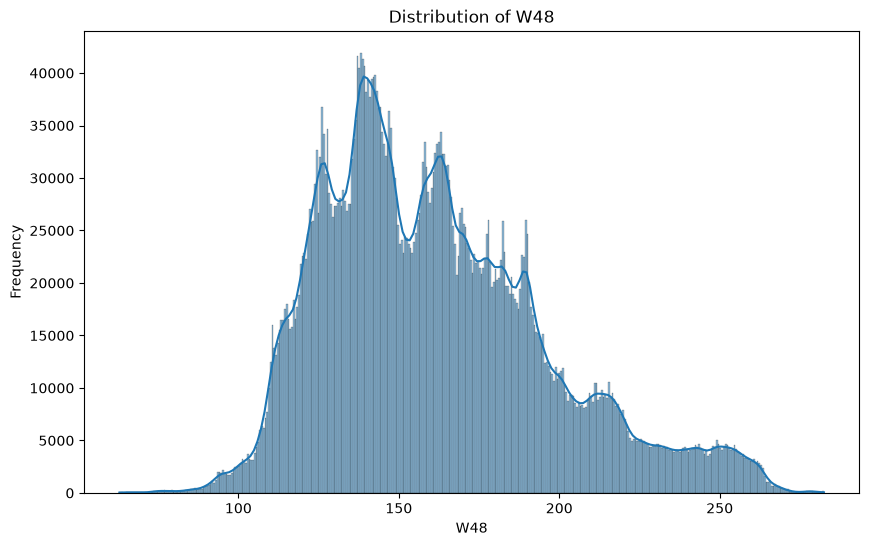

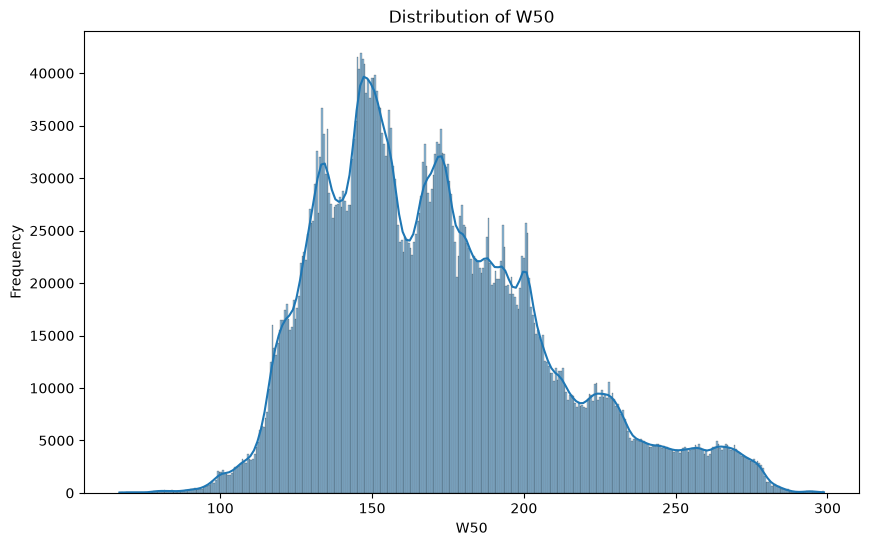

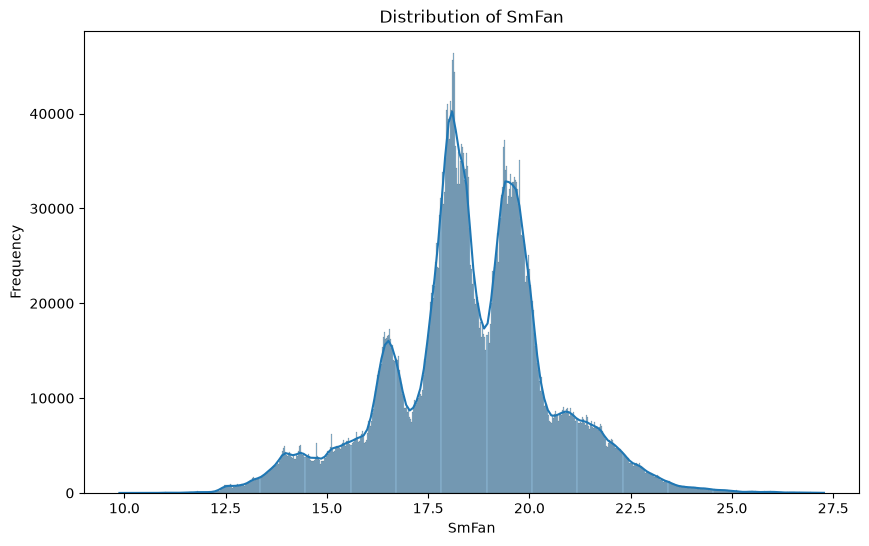

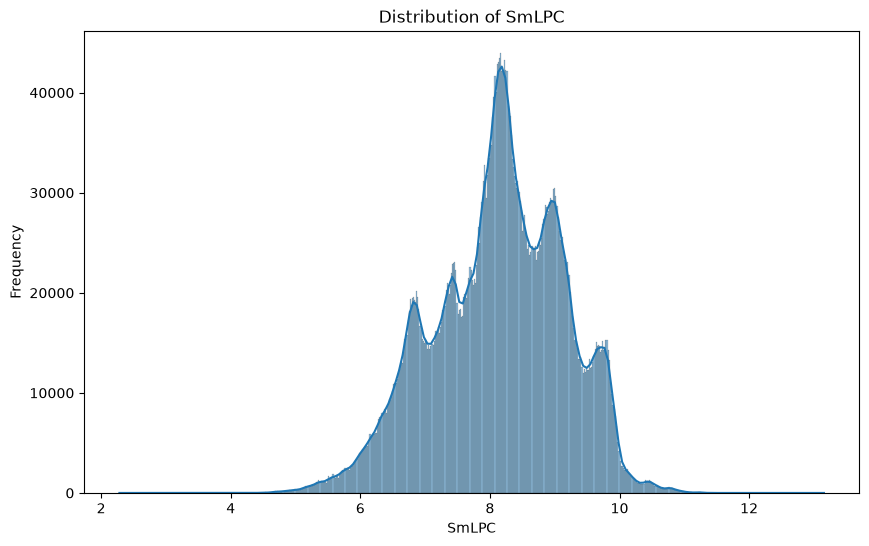

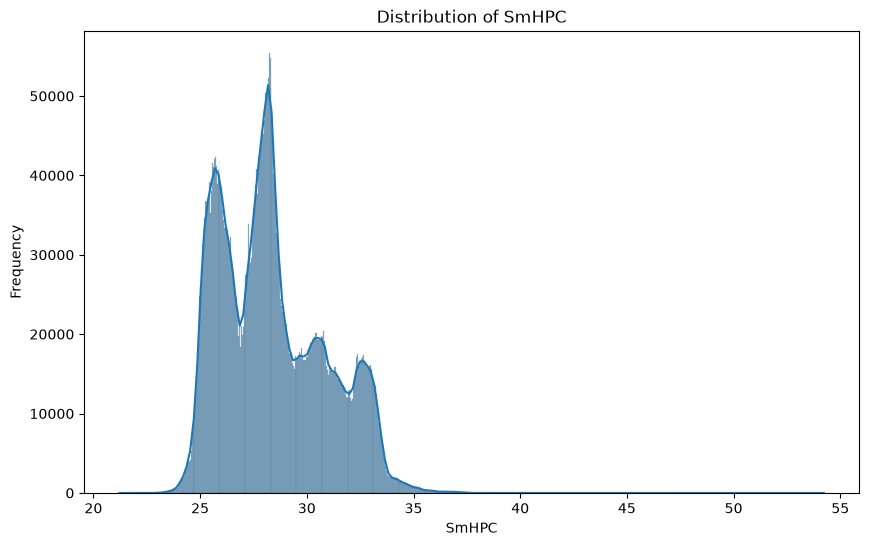

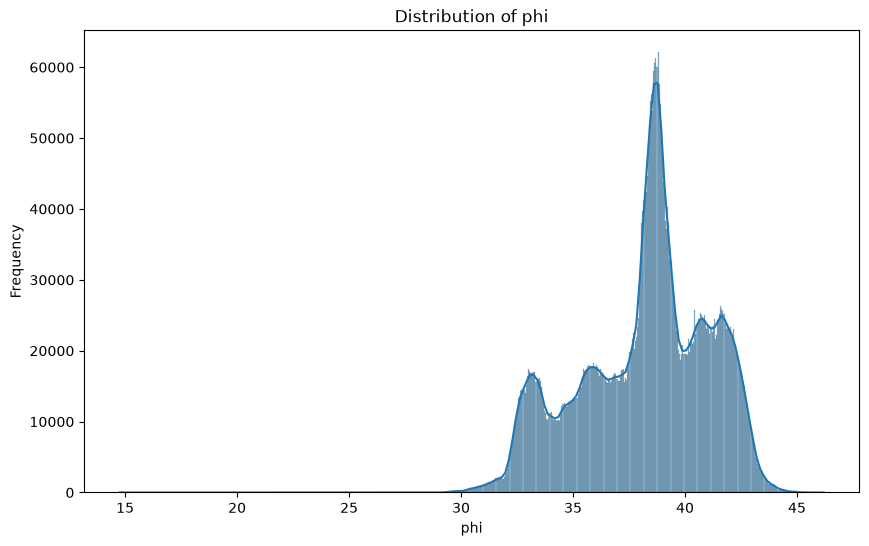

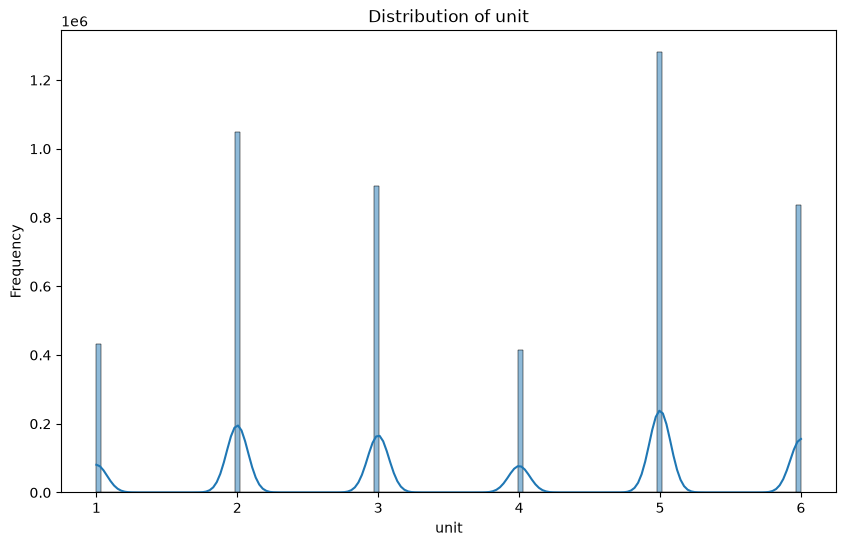

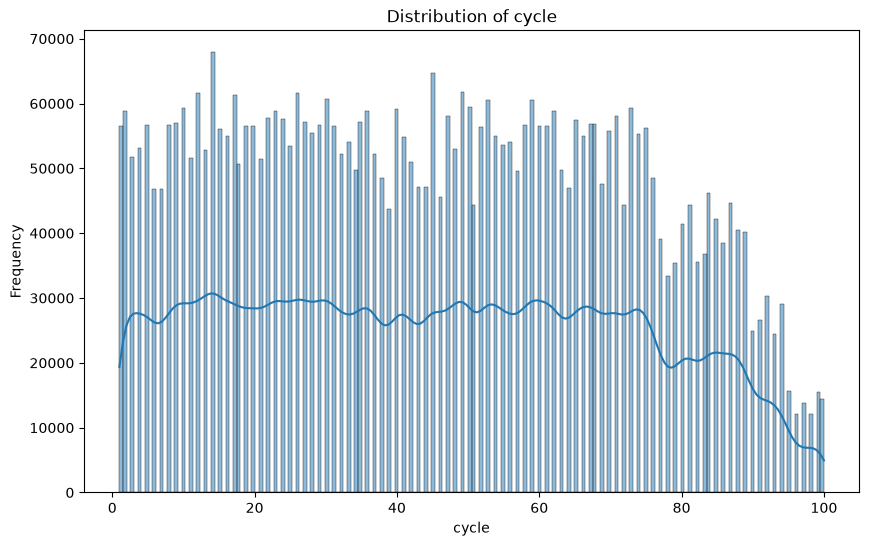

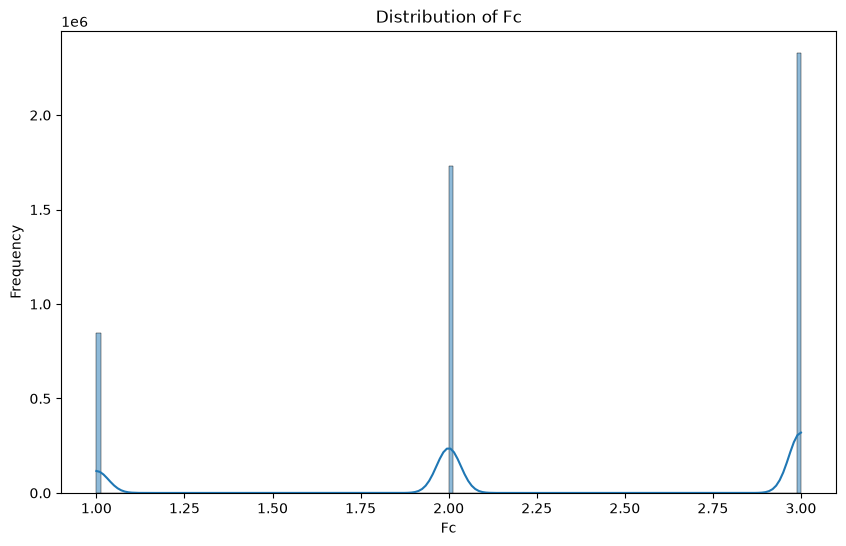

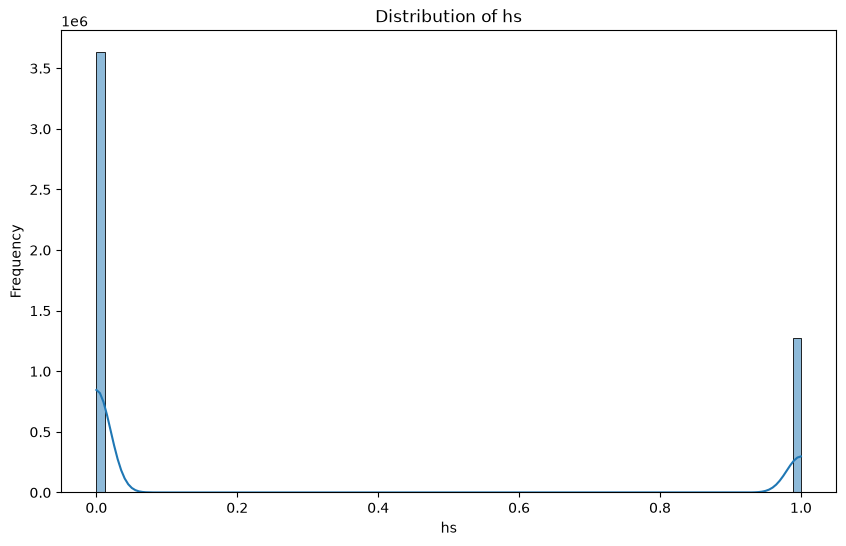

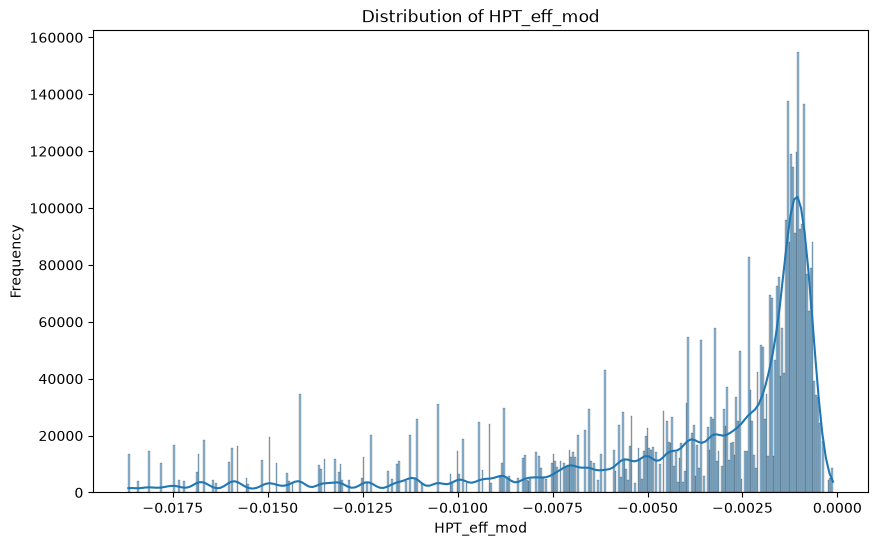

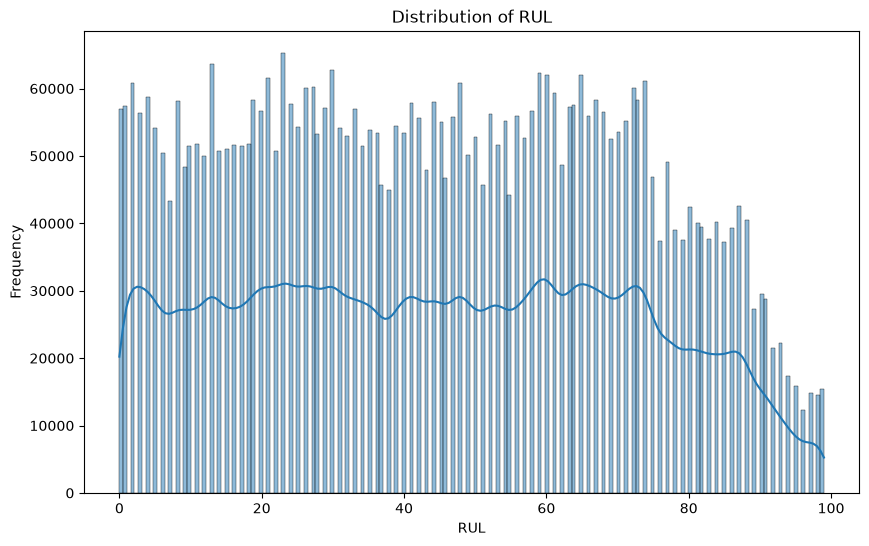

In [21]:
for col in train_df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(train_df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.savefig(f"../docs/figs/Distribution_of_{col}.png", bbox_inches='tight')
    plt.show()

In [22]:
train_df["RUL"].max()

np.int64(99)

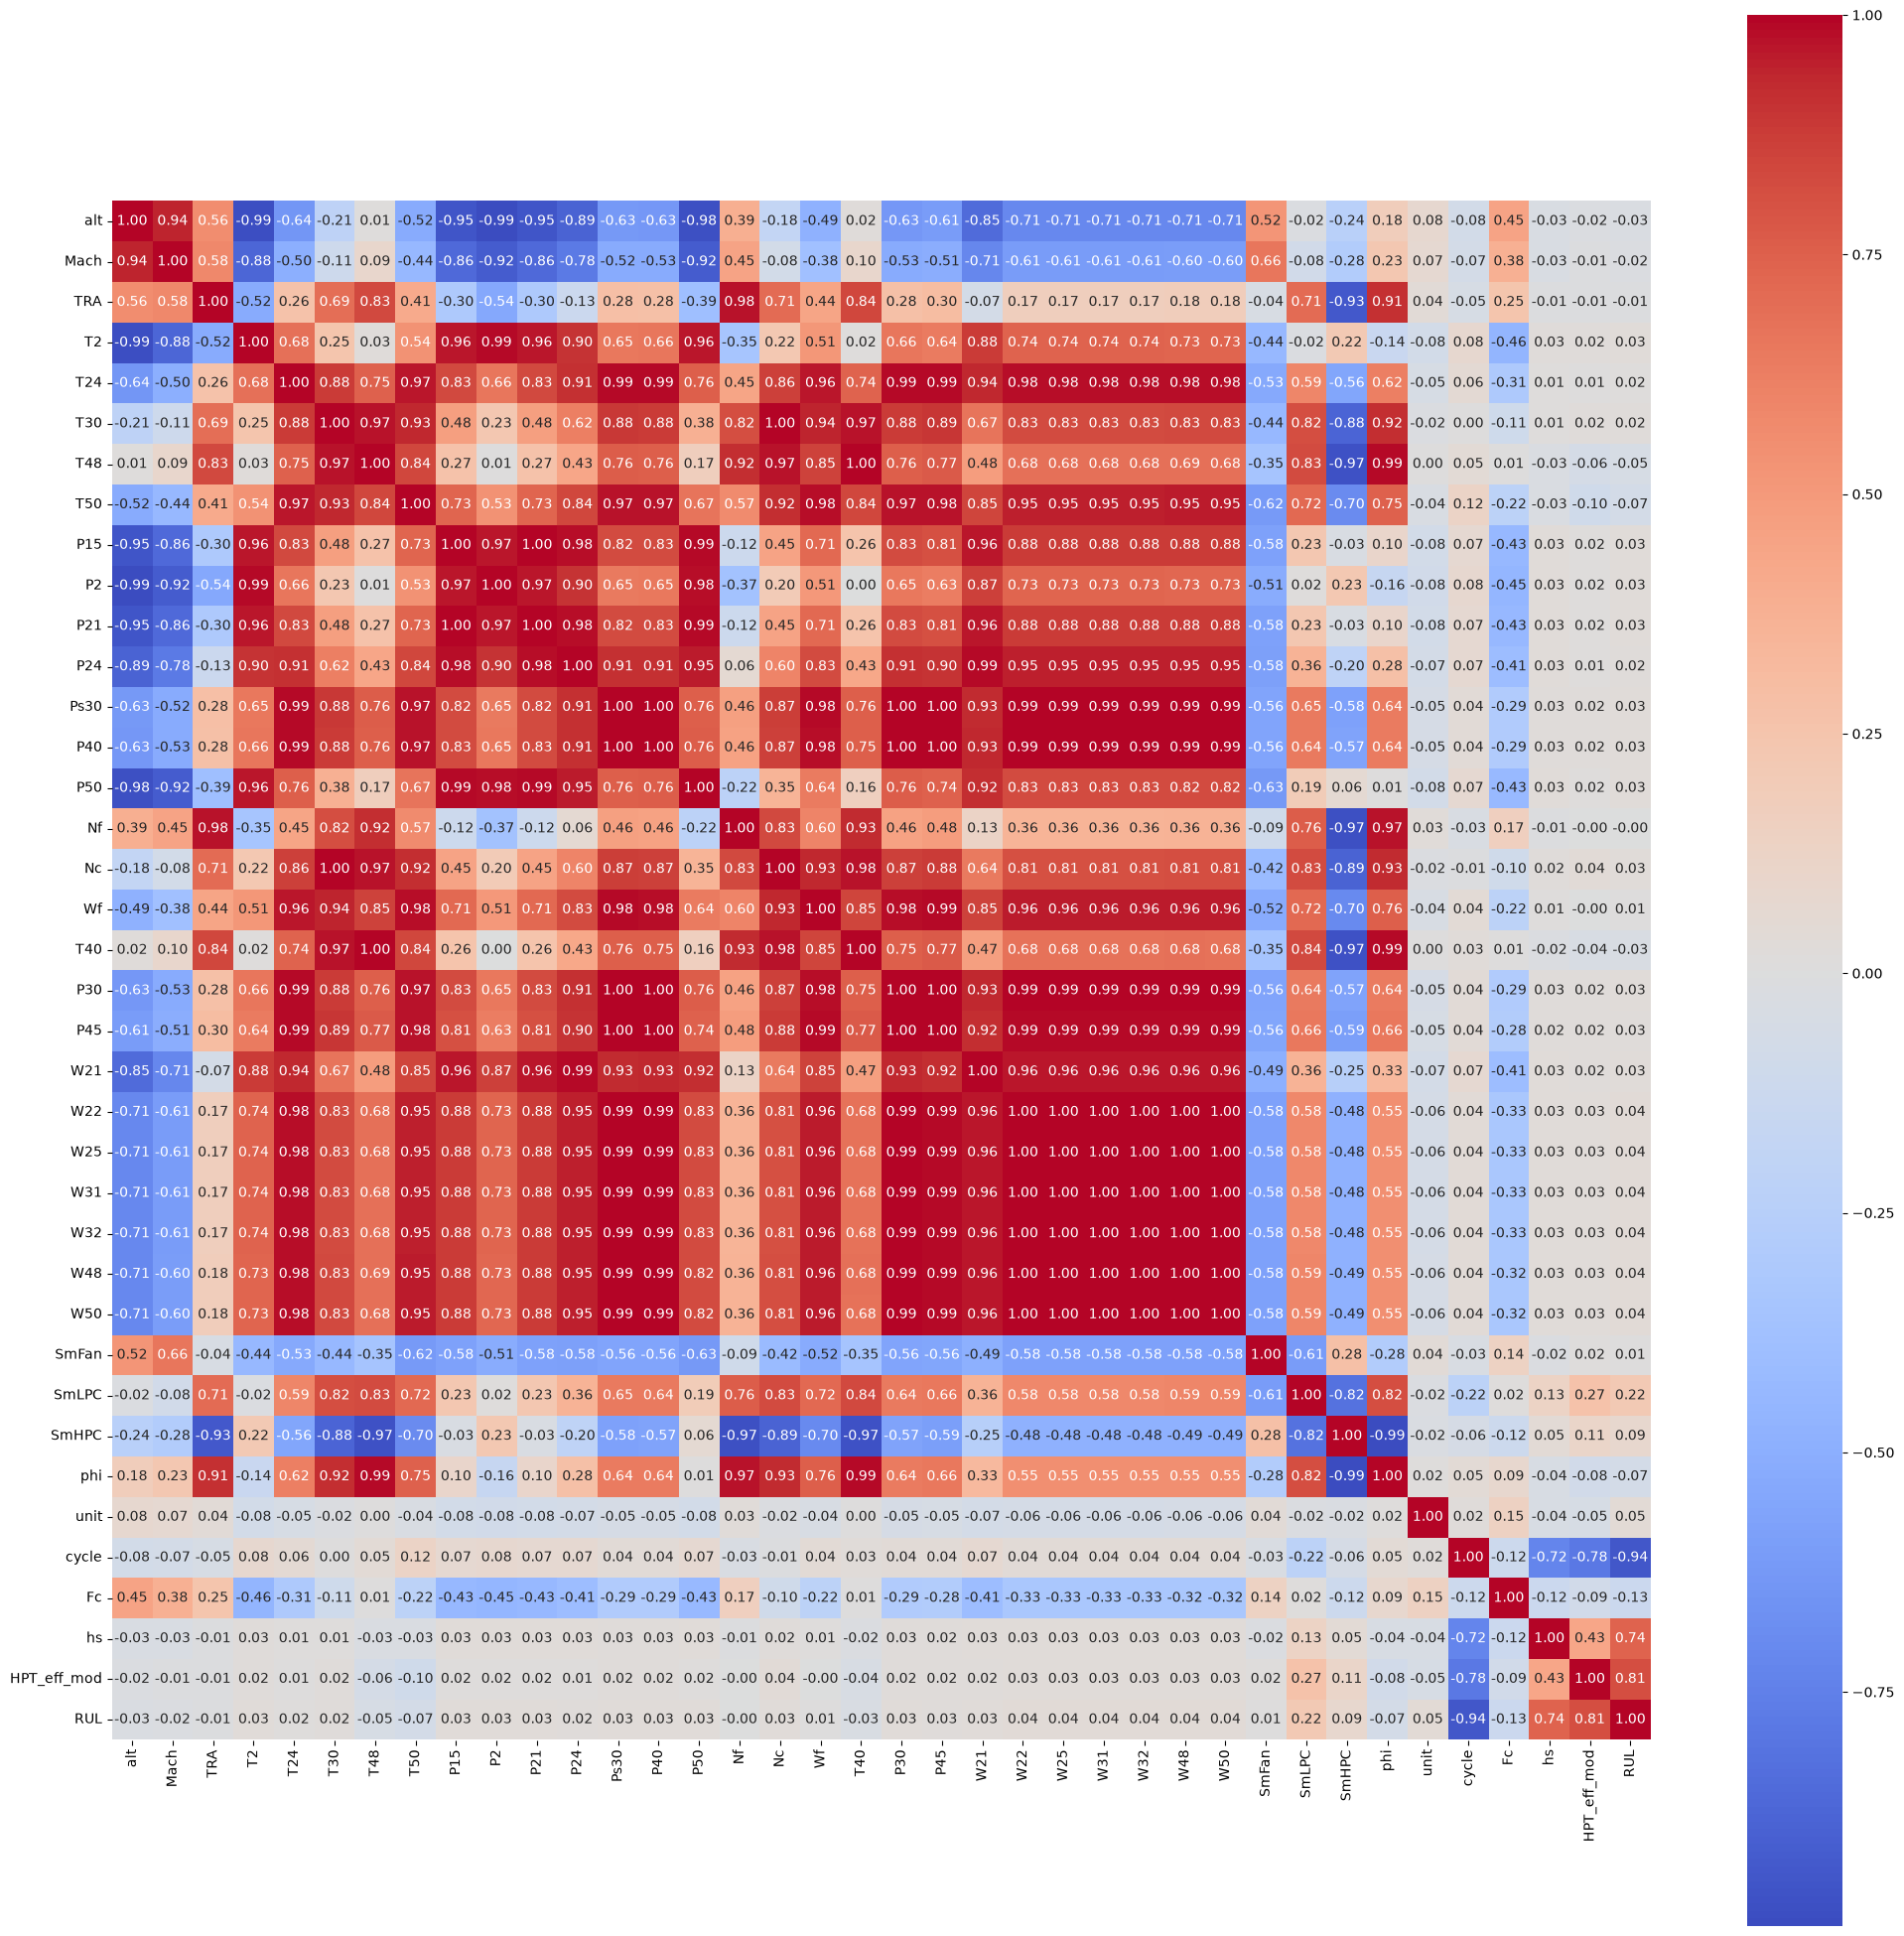

In [23]:
corr = train_df.corr()

plt.figure(figsize=(25, 25))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.savefig(f"../docs/figs/correlation_matrix.png", bbox_inches='tight')
plt.show()

In [24]:
train_df["Fc"].unique()

array([1., 3., 2.])

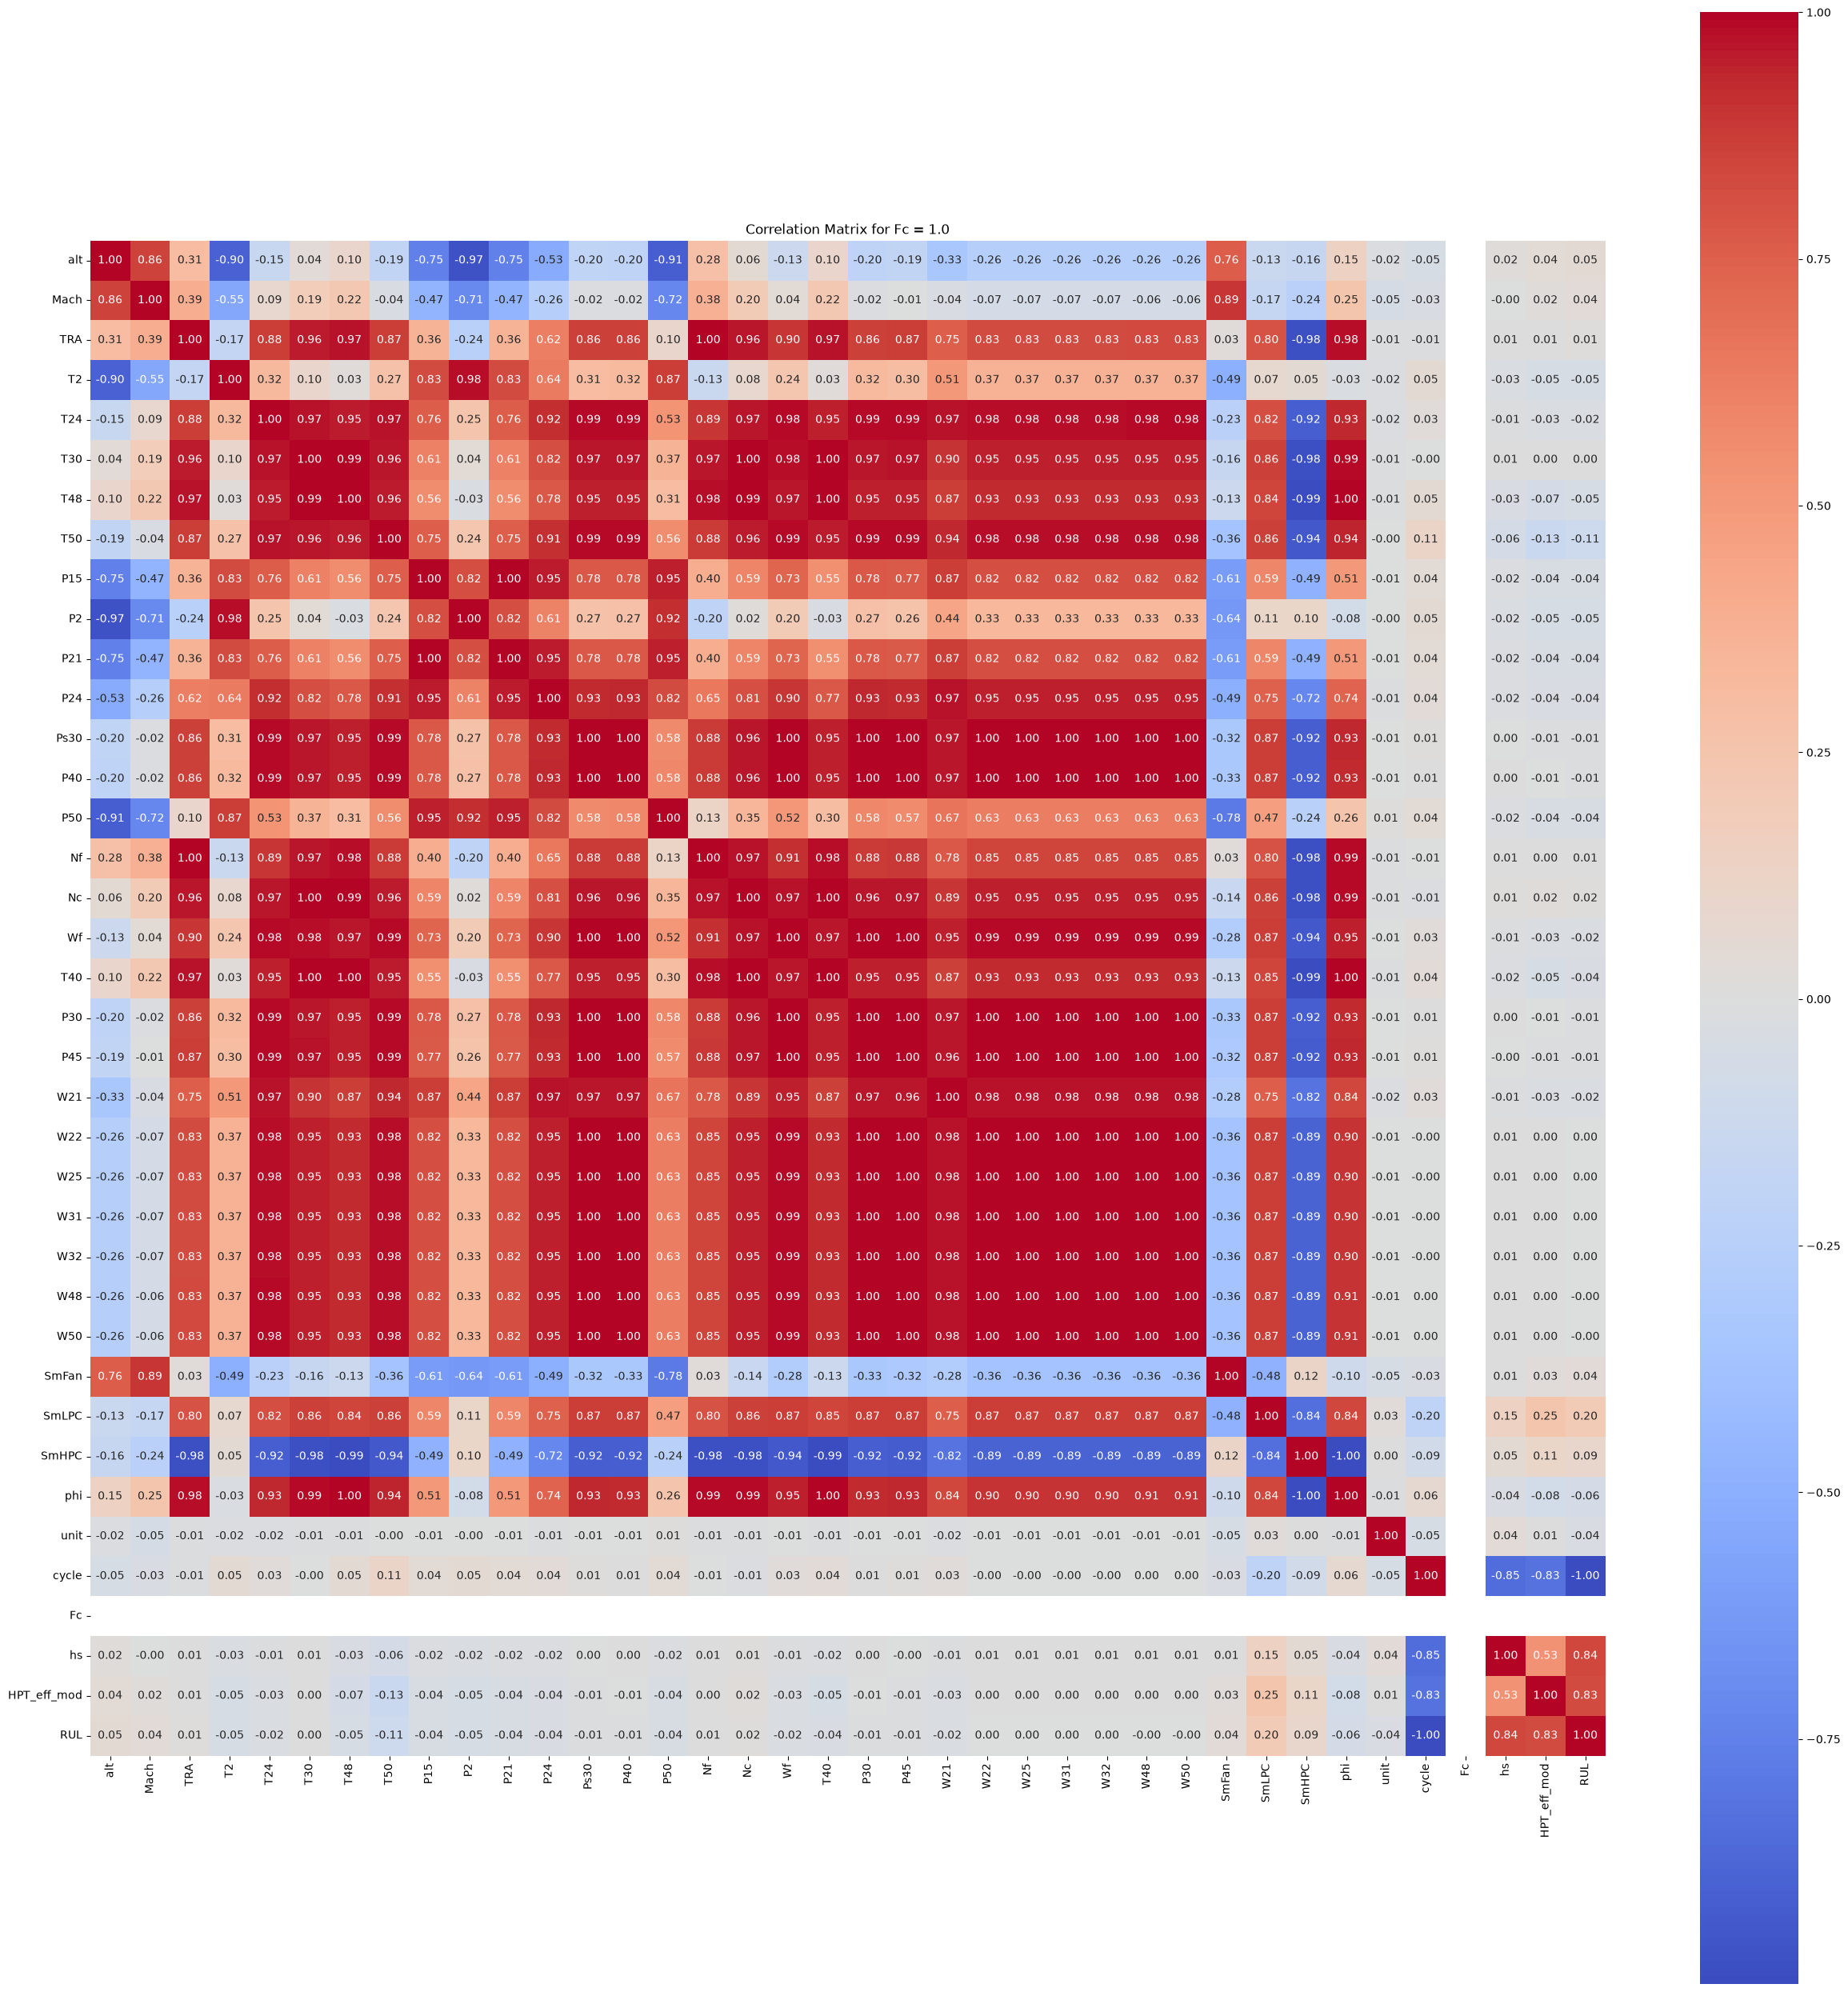

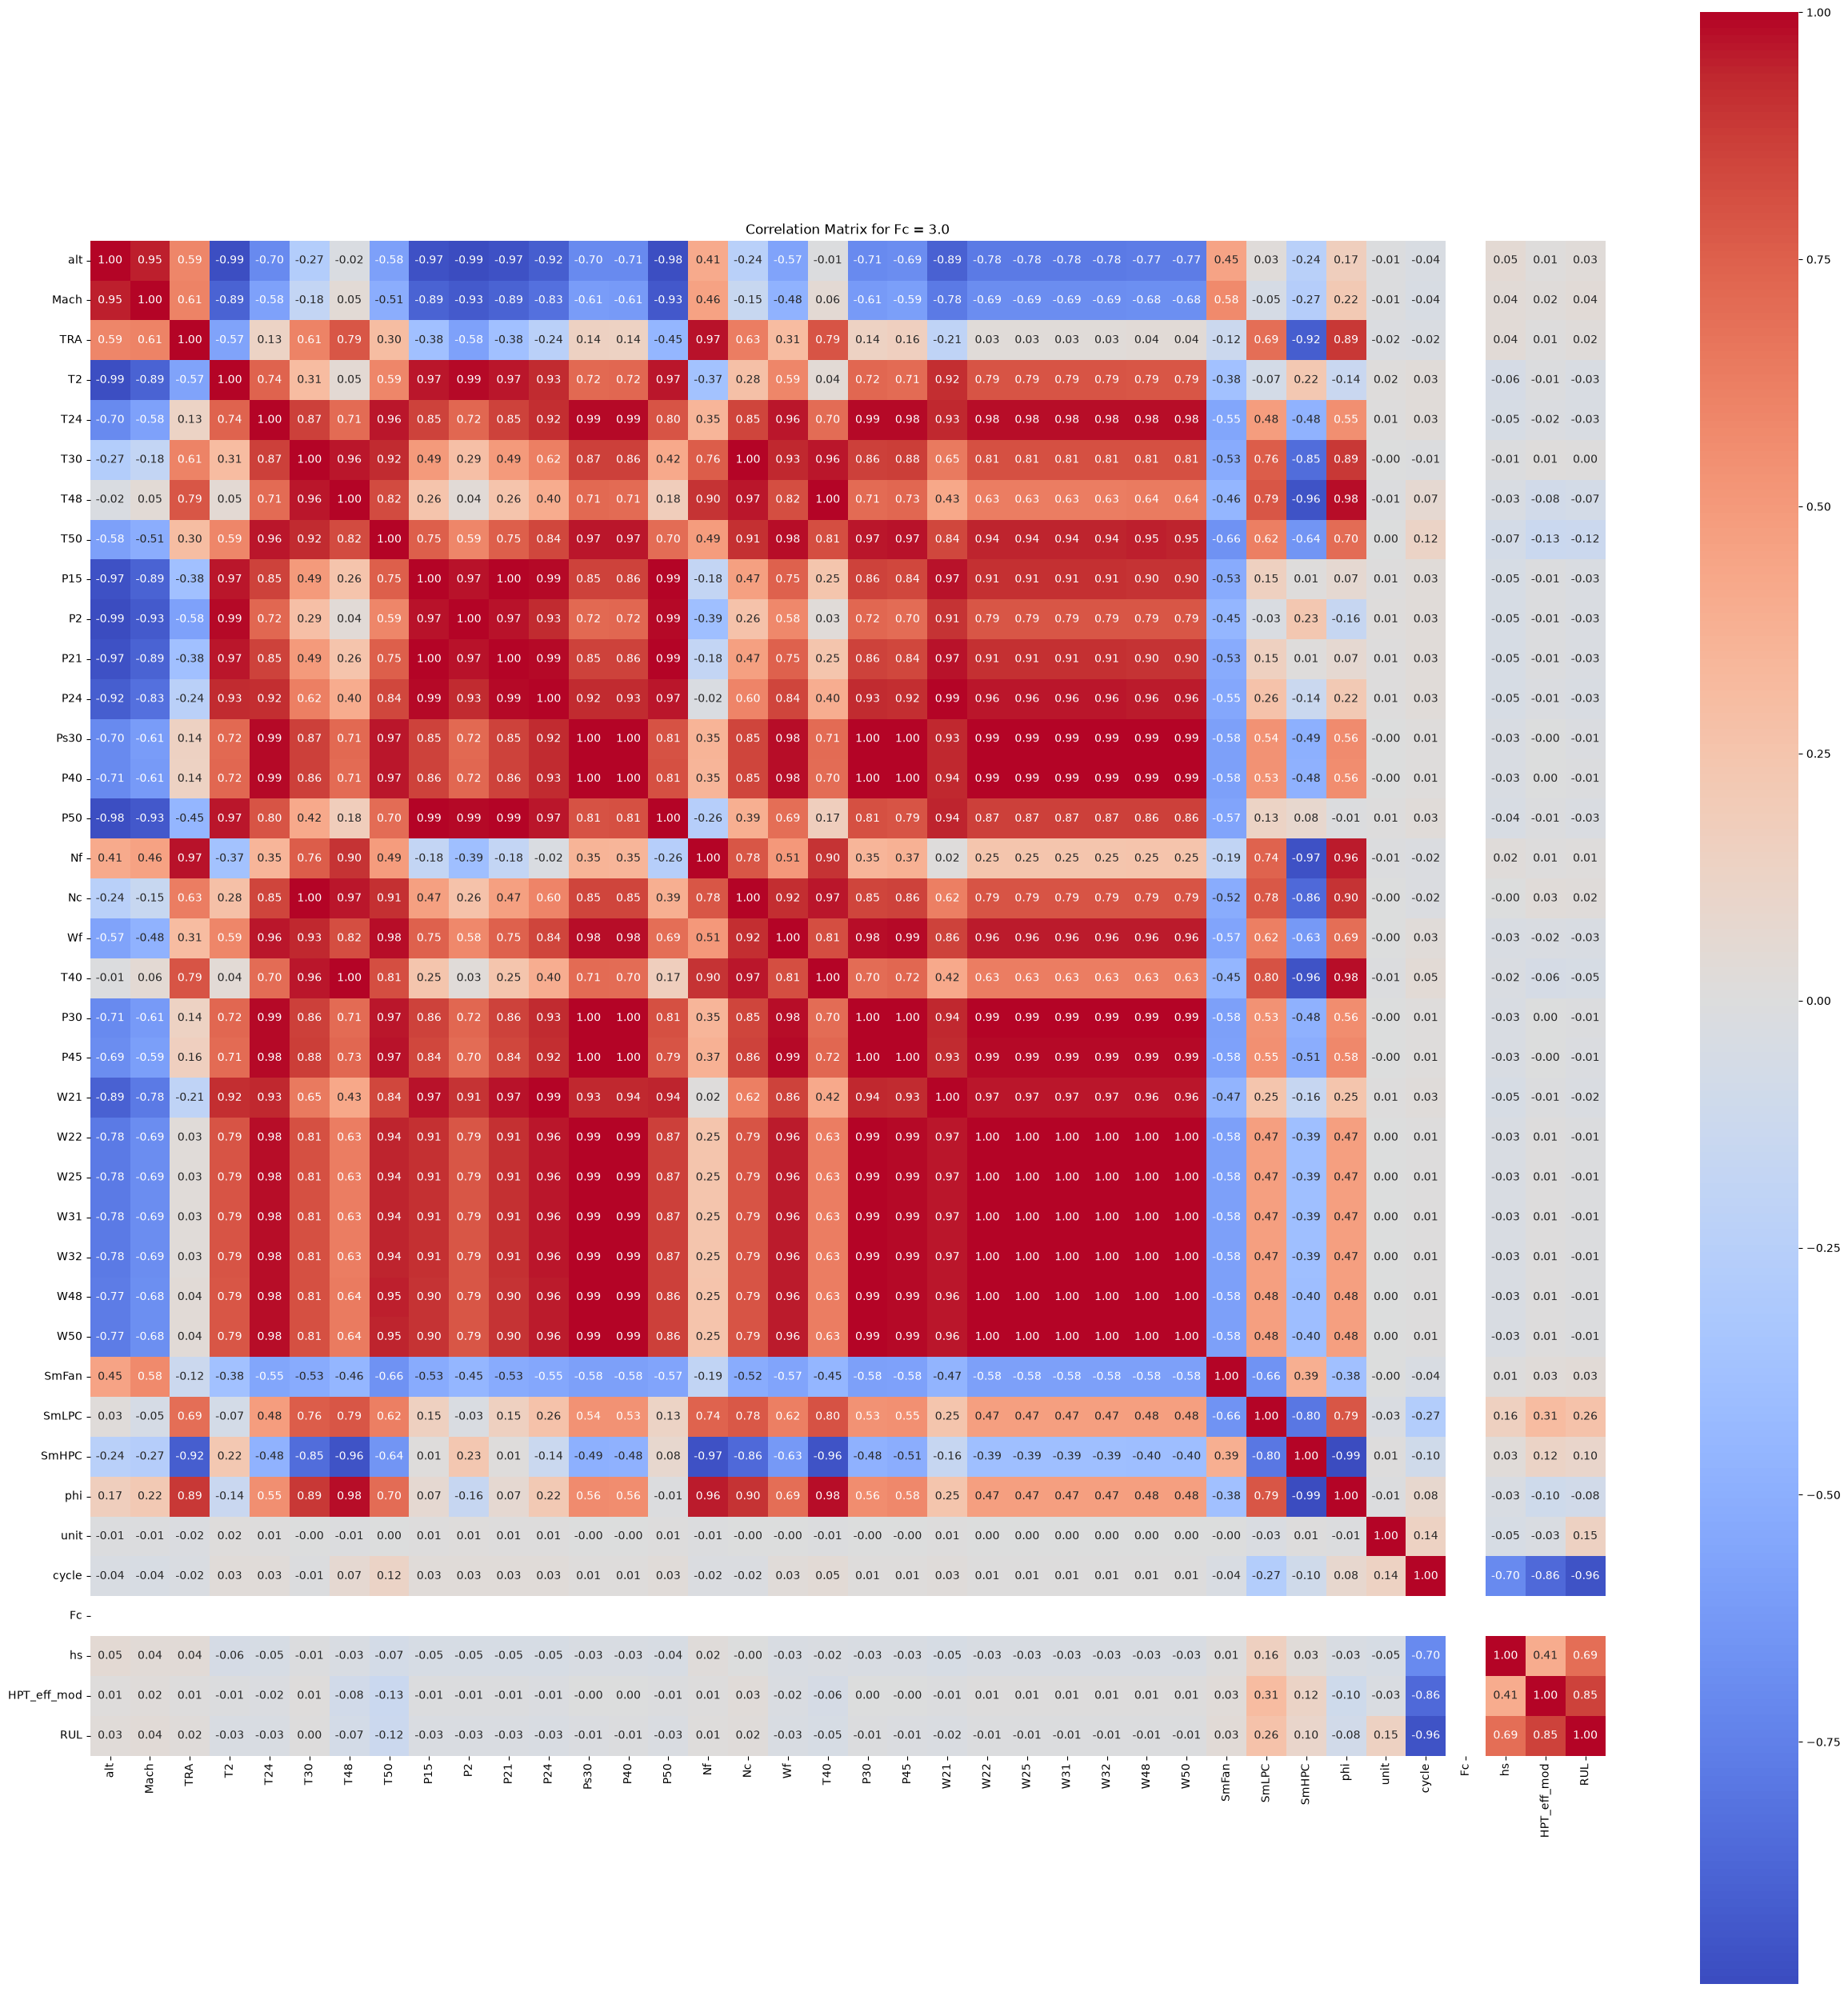

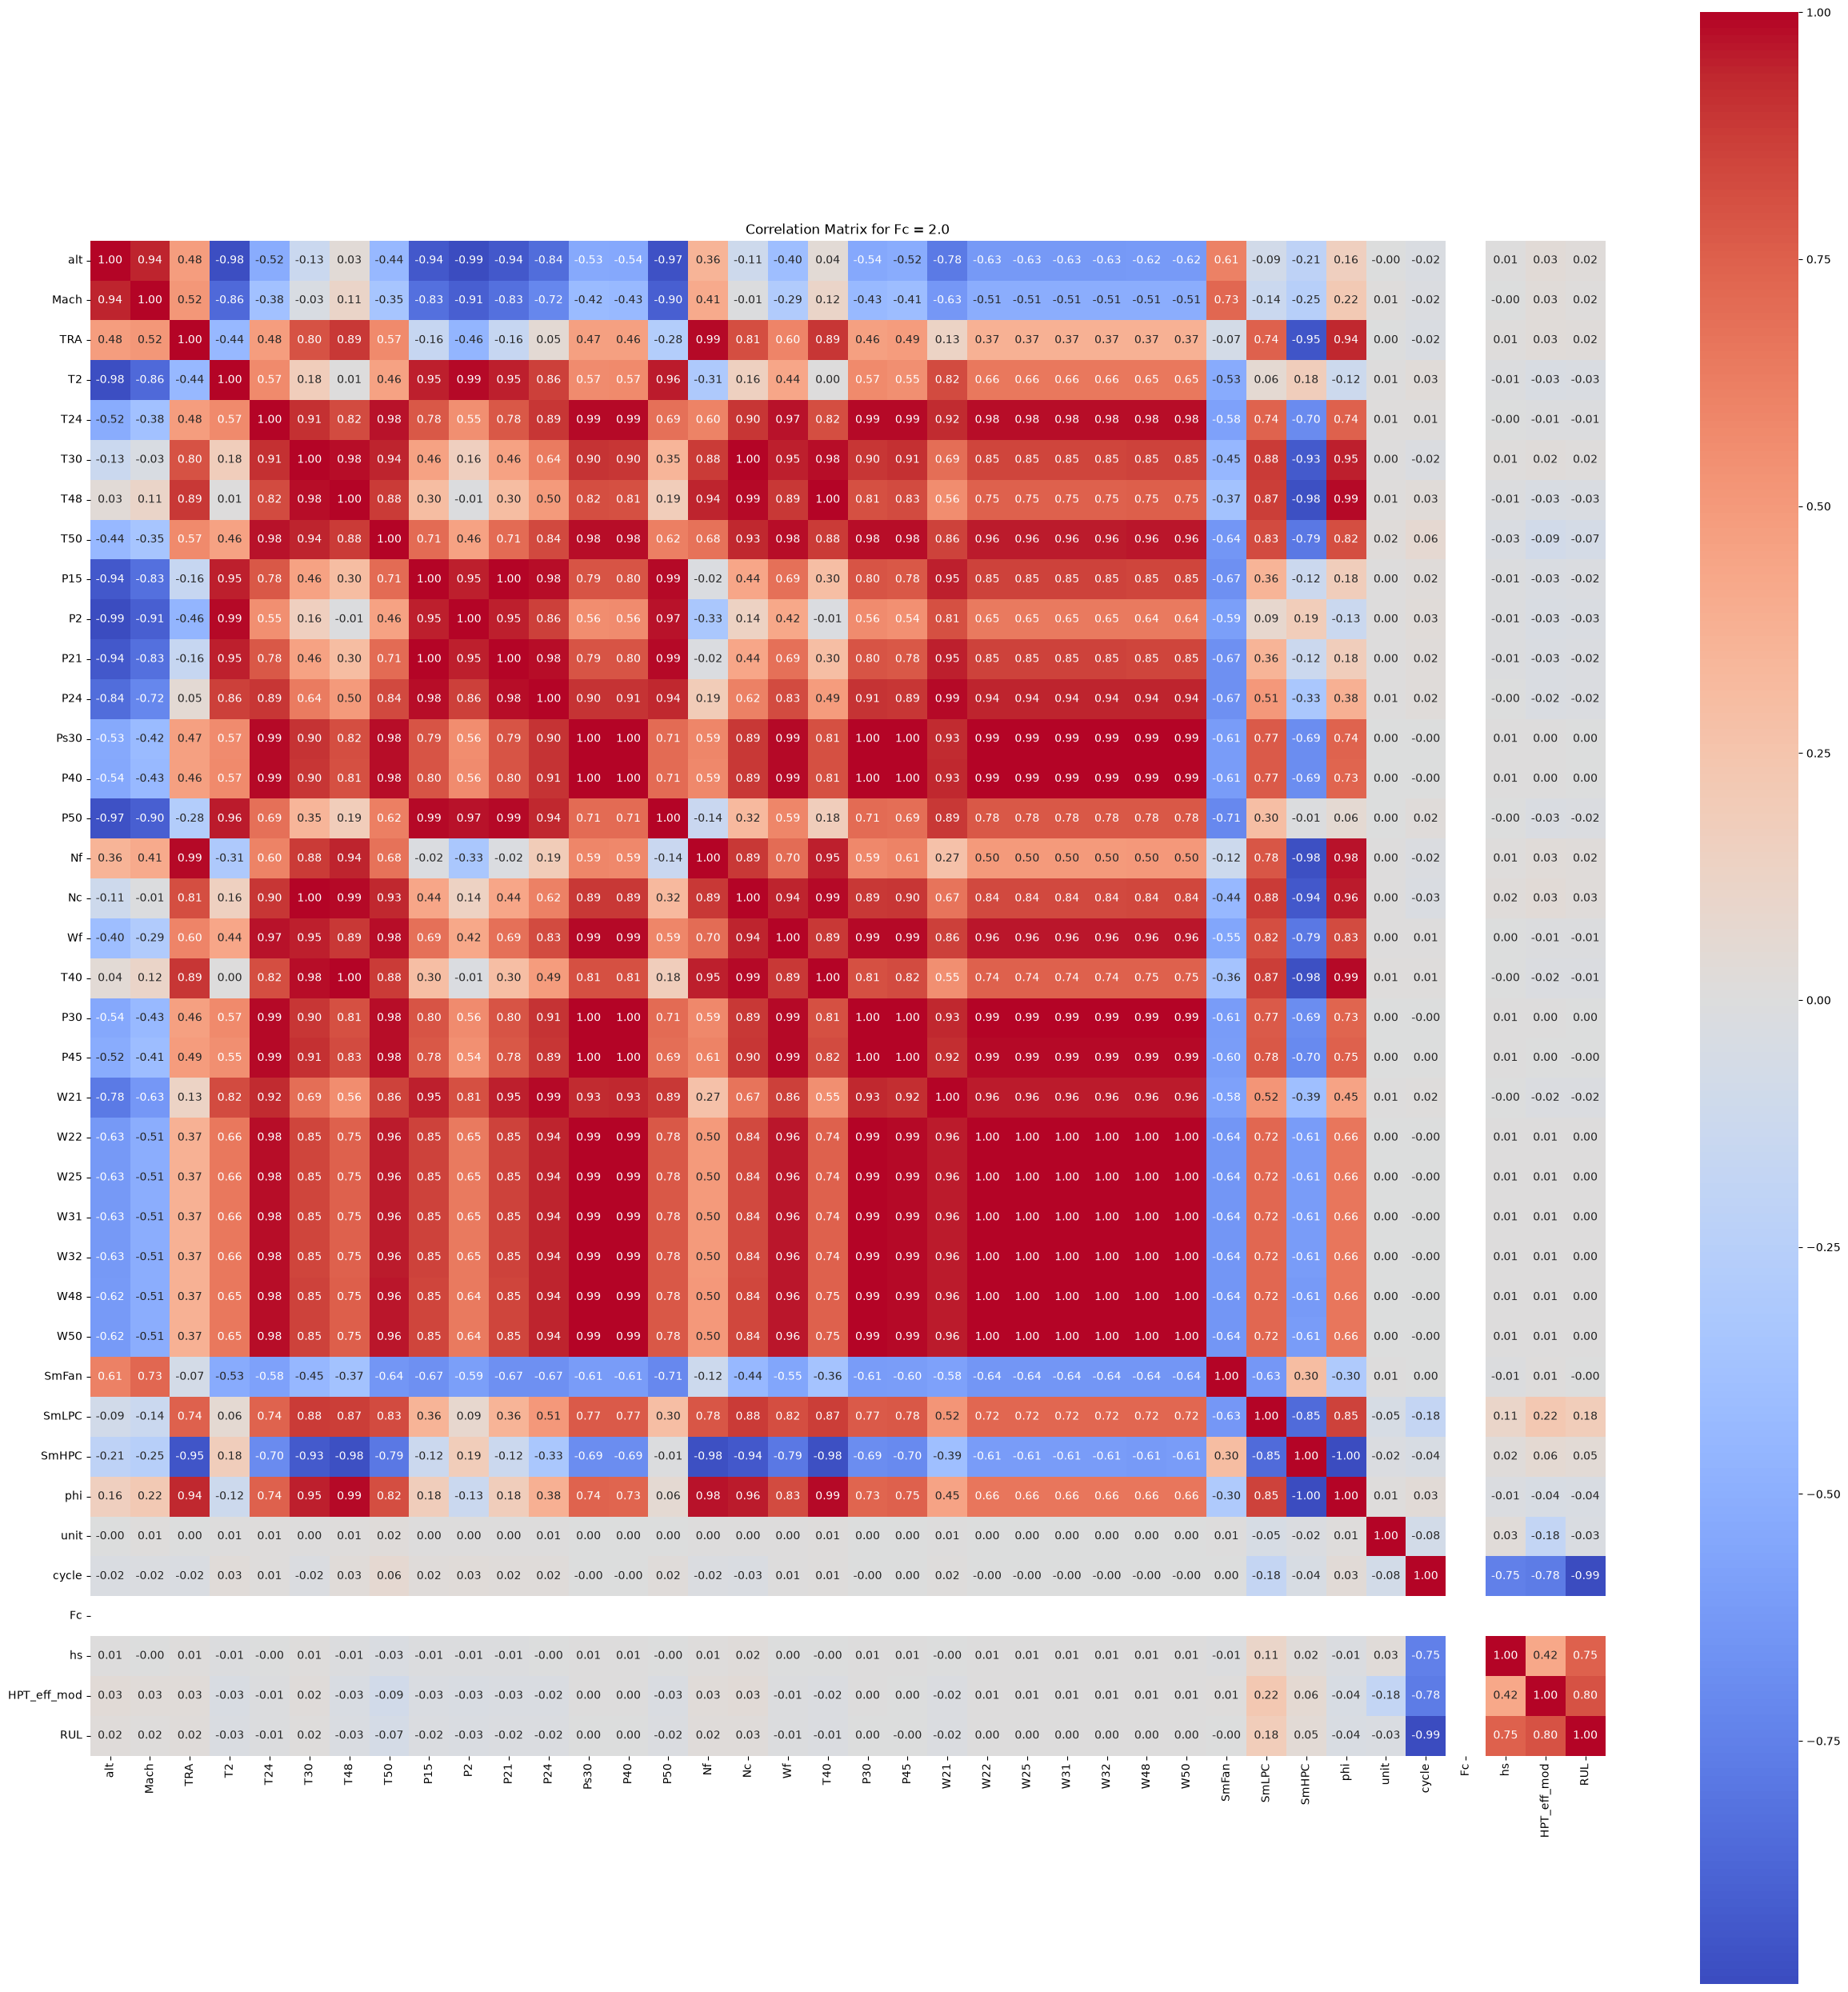

In [25]:
fc_values = train_df["Fc"].unique()


for fc in fc_values:
    plt.figure(figsize=(25, 25))
    
    df_fc = train_df[train_df["Fc"] == fc]
    
    fc_corr_matrix = df_fc.corr()
    
    sns.heatmap(fc_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title(f"Correlation Matrix for Fc = {fc}")
    plt.savefig(f"../docs/figs/correlation_matrix_Fc_{fc}.png", bbox_inches='tight')
    plt.tight_layout()
    plt.show()

In [26]:
train_df.columns

Index(['alt', 'Mach', 'TRA', 'T2', 'T24', 'T30', 'T48', 'T50', 'P15', 'P2',
       'P21', 'P24', 'Ps30', 'P40', 'P50', 'Nf', 'Nc', 'Wf', 'T40', 'P30',
       'P45', 'W21', 'W22', 'W25', 'W31', 'W32', 'W48', 'W50', 'SmFan',
       'SmLPC', 'SmHPC', 'phi', 'unit', 'cycle', 'Fc', 'hs', 'HPT_eff_mod',
       'RUL'],
      dtype='str')

In [27]:
from sklearn.linear_model import LinearRegression

sensors_names = [col for col in train_df.columns if col not in ["alt", "Mach", "TRA", "cycle", "unit", "RUL", "Fc", "hs"]]

X_df = train_df[["alt", "Mach", "TRA"]]

Predicted_results = pd.DataFrame()
Residuals = pd.DataFrame()
for sensor in sensors_names:
    model = LinearRegression()
    
    model.fit(X_df, train_df[sensor])
    
    Predicted_results[sensor] = model.predict(X_df)

for sensor in sensors_names:
    Residuals[sensor] = train_df[sensor] - Predicted_results[sensor]
    
Residuals["RUL"] = train_df["RUL"]


In [28]:
Residuals.shape

(4906636, 31)

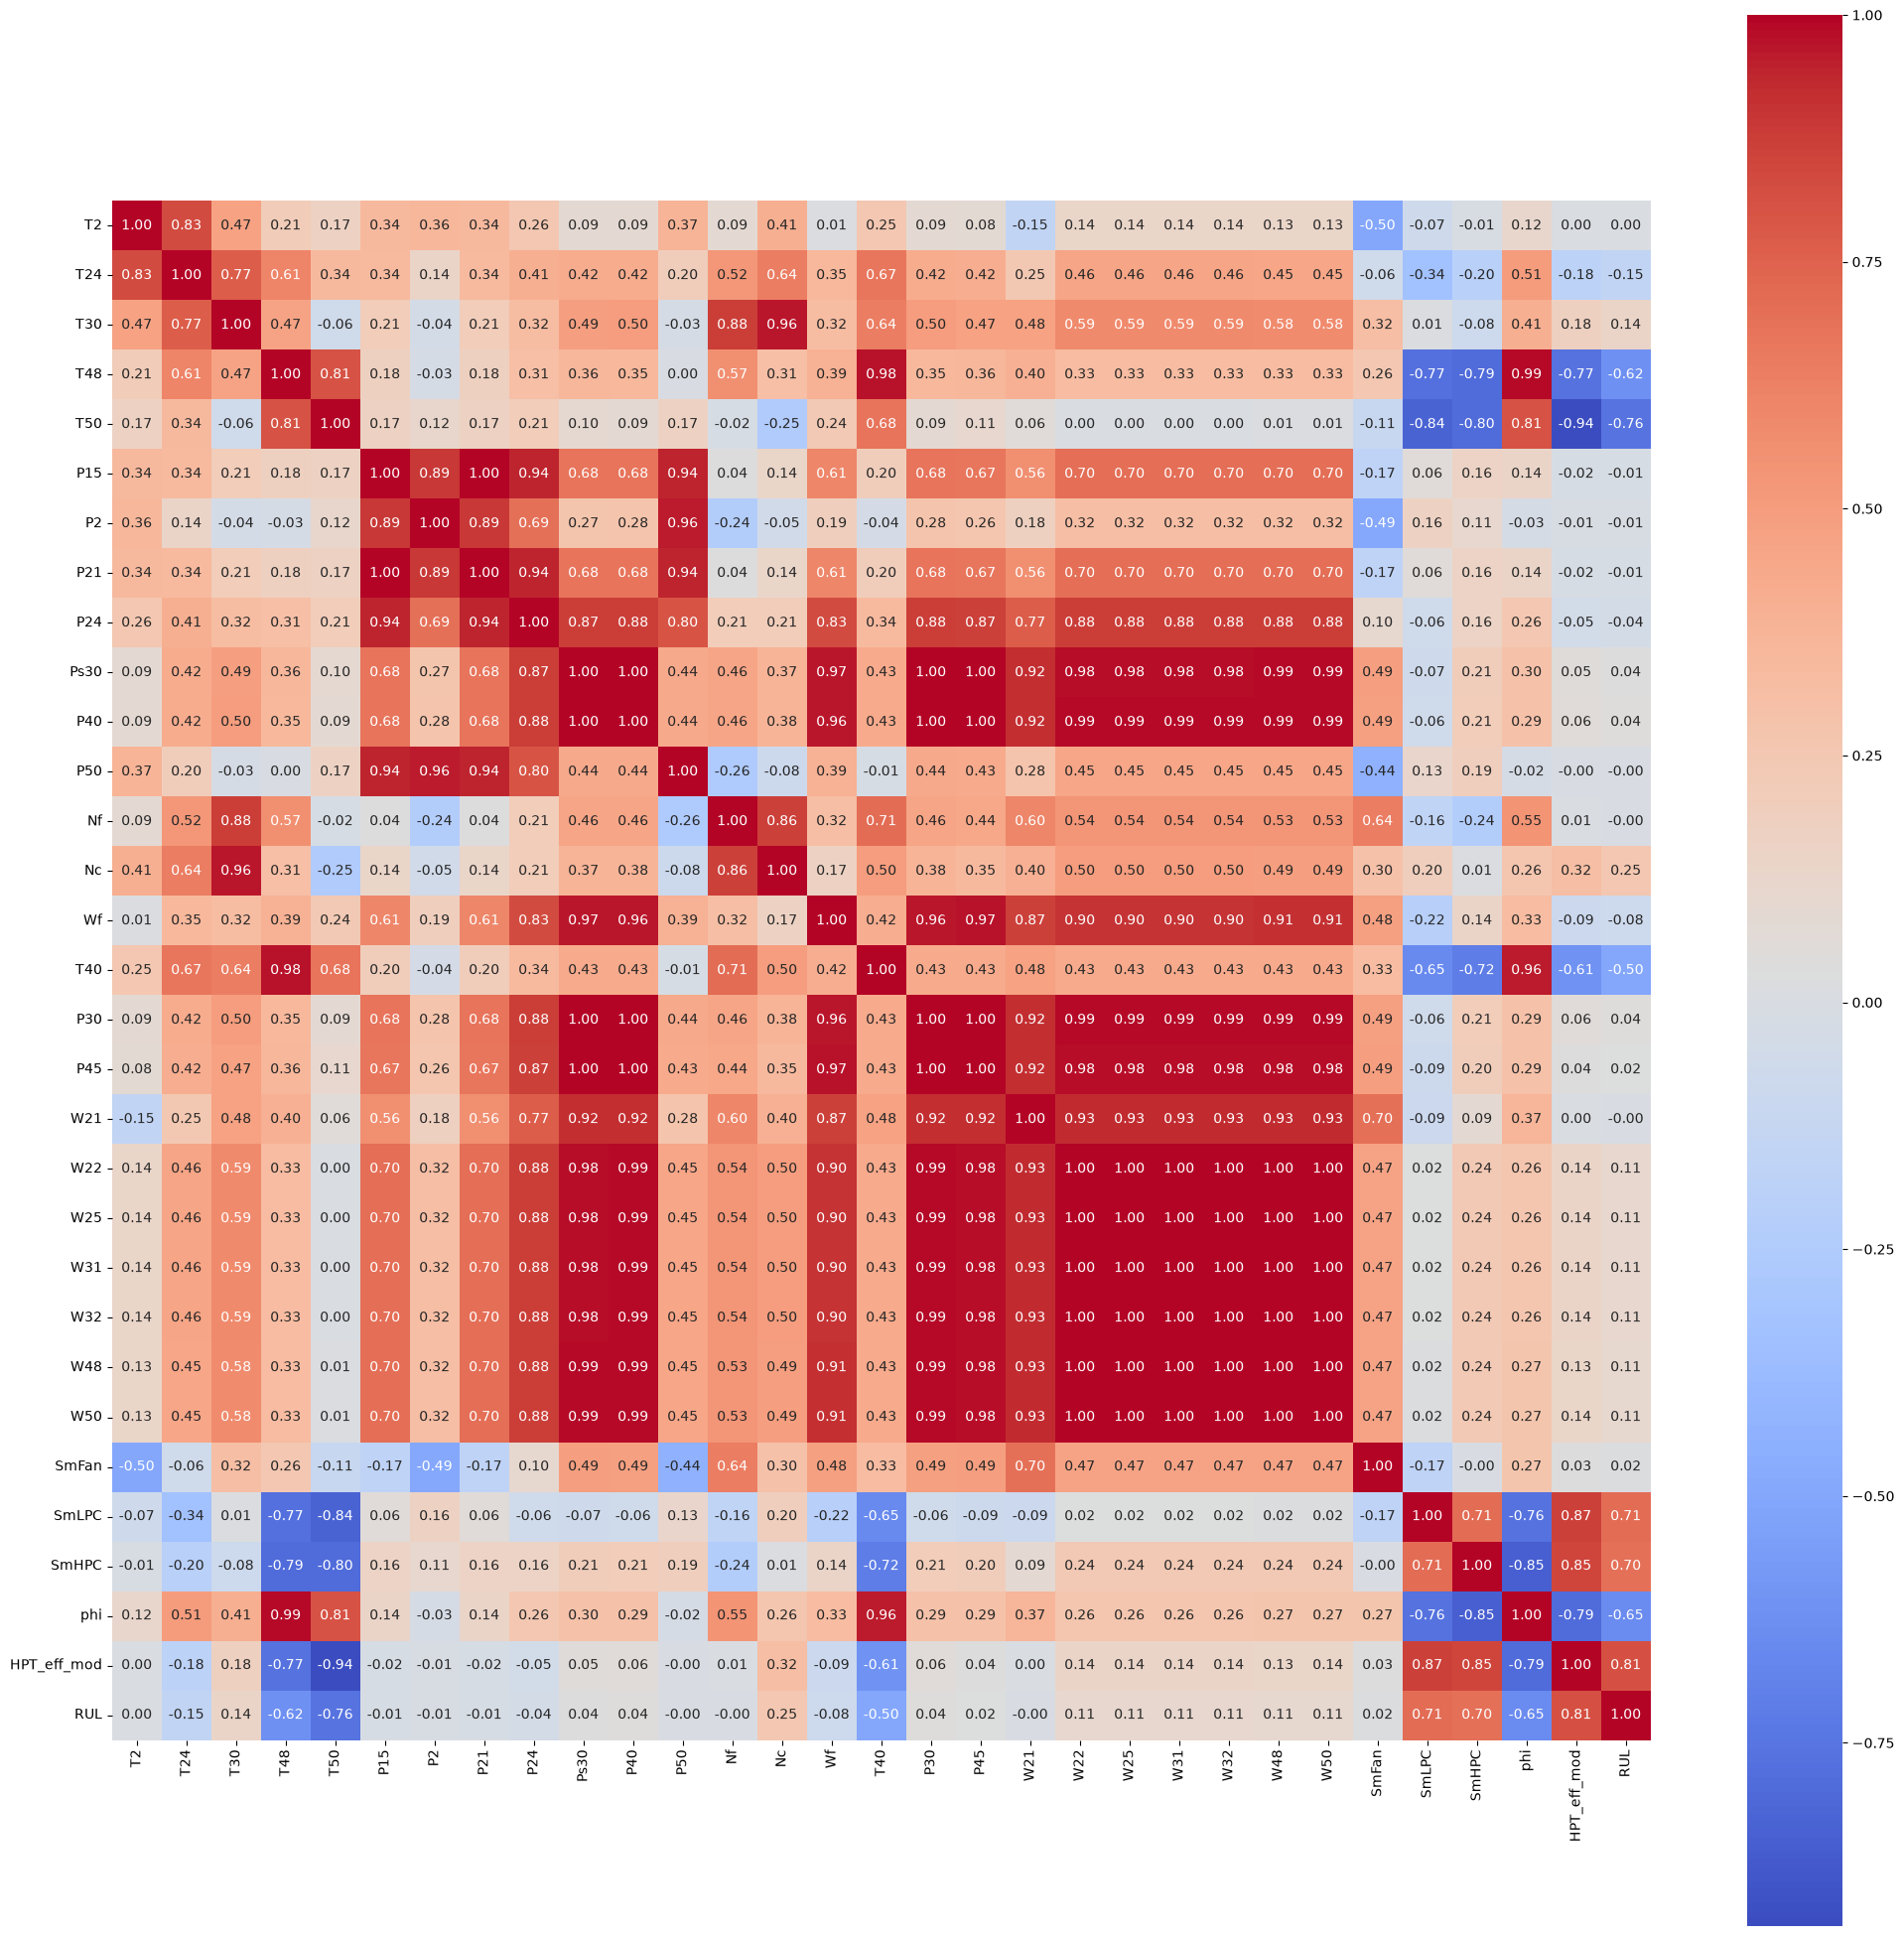

In [29]:
Residuals_corr = Residuals.corr()

plt.figure(figsize=(25, 25))
sns.heatmap(Residuals_corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.savefig(f"../docs/figs/Residuals_correlation_matrix.png", bbox_inches="tight")
plt.show()

### Saving dataset

In [30]:
train_df.to_csv("../data/cleaned/train_cleaned.csv", index=False)

### Extracting test Dataset

In [31]:
with h5py.File("../data/raw/N-CMAPSS_DS01-005.h5", "r") as f:
    print(f.keys())

<KeysViewHDF5 ['A_dev', 'A_test', 'A_var', 'T_dev', 'T_test', 'T_var', 'W_dev', 'W_test', 'W_var', 'X_s_dev', 'X_s_test', 'X_s_var', 'X_v_dev', 'X_v_test', 'X_v_var', 'Y_dev', 'Y_test']>


In [32]:
# Create Training dataset
with h5py.File("../data/raw/N-CMAPSS_DS01-005.h5", "r") as f:
    W_var = f["W_var"][:]
    X_s_var = f["X_s_var"][:]
    X_v_var = f["X_v_var"][:]
    A_var = f["A_var"][:]
    T_var = f["T_var"][:]
    # no y because it is not a variable, but a label
    
    W_test = f["W_test"][:]
    X_s_test = f["X_s_test"][:]
    X_v_test = f["X_v_test"][:]
    A_test = f["A_test"][:]
    T_test = f["T_test"][:]
    Y_test = f["Y_test"][:]

# Decode bytes to strings for variable names    
W_var = [var.decode("utf-8") for var in W_var if isinstance(var, bytes)]
X_s_var = [var.decode("utf-8") for var in X_s_var if isinstance(var, bytes)]
X_v_var = [var.decode("utf-8") for var in X_v_var if isinstance(var, bytes)]
A_var = [var.decode("utf-8") for var in A_var if isinstance(var, bytes)]
T_var = [var.decode("utf-8") for var in T_var if isinstance(var, bytes)]


# Create a DataFrame for the training dataset
W_df = pd.DataFrame(W_test, columns=W_var)
X_s_df = pd.DataFrame(X_s_test, columns=X_s_var)
X_v_df = pd.DataFrame(X_v_test, columns=X_v_var)
A_df = pd.DataFrame(A_test, columns=A_var)
T_df = pd.DataFrame(T_test, columns=T_var)
Y_df = pd.DataFrame(Y_test, columns=["RUL"])

# concatenate all the DataFrames into a single DataFrame
test_df = pd.concat([W_df, X_s_df, X_v_df, A_df, T_df, Y_df], axis=1)

In [33]:
test_df.shape

(2735232, 47)

In [34]:
test_df.head()

,alt,Mach,TRA,T2,T24,T30,T48,T50,P15,P2,...,fan_flow_mod,LPC_eff_mod,LPC_flow_mod,HPC_eff_mod,HPC_flow_mod,HPT_eff_mod,HPT_flow_mod,LPT_eff_mod,LPT_flow_mod,RUL
0,3002.0,0.356832,75.497513,520.902124,621.674181,1488.551493,1885.475241,1286.679674,19.571523,14.347092,...,0.0,0.0,0.0,0.0,0.0,-0.000294,0.0,0.0,0.0,89
1,3012.0,0.358722,75.497513,520.998906,621.752333,1488.649010,1885.710506,1286.797034,19.579783,14.354987,...,0.0,0.0,0.0,0.0,0.0,-0.000294,0.0,0.0,0.0,89
2,3021.0,0.358911,75.497513,520.981786,621.752887,1488.614773,1885.475391,1286.549261,19.576369,14.351740,...,0.0,0.0,0.0,0.0,0.0,-0.000294,0.0,0.0,0.0,89
3,3027.0,0.358911,75.497513,520.959729,621.722013,1488.535686,1885.397382,1286.502521,19.571636,14.348539,...,0.0,0.0,0.0,0.0,0.0,-0.000294,0.0,0.0,0.0,89
4,3031.0,0.359037,75.497513,520.954503,621.711675,1488.507278,1885.369727,1286.480744,19.569790,14.347373,...,0.0,0.0,0.0,0.0,0.0,-0.000294,0.0,0.0,0.0,89


In [35]:
zero_columns = ["fan_eff_mod", "fan_flow_mod", "LPC_eff_mod", "LPC_flow_mod", "HPC_eff_mod", "HPC_flow_mod", "HPT_flow_mod", "LPT_flow_mod", "LPT_eff_mod"]

test_df.drop(columns=zero_columns, inplace=True)

In [36]:
test_df.isna().sum()

alt            0
Mach           0
TRA            0
T2             0
T24            0
T30            0
T48            0
T50            0
P15            0
P2             0
P21            0
P24            0
Ps30           0
P40            0
P50            0
Nf             0
Nc             0
Wf             0
T40            0
P30            0
P45            0
W21            0
W22            0
W25            0
W31            0
W32            0
W48            0
W50            0
SmFan          0
SmLPC          0
SmHPC          0
phi            0
unit           0
cycle          0
Fc             0
hs             0
HPT_eff_mod    0
RUL            0
dtype: int64

In [37]:
test_df.duplicated().sum()

np.int64(0)

In [38]:
test_df.to_csv("../data/cleaned/test_cleaned.csv", index=False)

## EDA Summary & Feature Candidates

### Dataset Overview
- Development set: 6 units, ~4M rows total, highly imbalanced row counts per unit (unit 5 ≈ 1.28M rows, unit 4 ≈ 0.4M rows) due to varying trajectory lengths.
- No nulls, no duplicates. One dead (all-zero) column removed.
- Test set audit deferred until train pipeline is finalized as a reusable function.

### Target (RUL)
- RUL is pre-clipped in this dataset at a maximum of **99** (confirmed via `train_df["RUL"].max()`), not the commonly cited 125–130 used in other C-MAPSS variants.
- `R_early` for any future re-clipping (if raw/unclipped RUL is used elsewhere) should therefore be set to **99–100** for this dataset, not 125.
- RUL is treated as a **regression target** (discrete count, ordinal, not multiclass).

### Key Finding: Raw Sensor Correlations Are Misleading
- Raw sensor correlation with RUL is near-zero for almost all physical/virtual sensors (e.g., T50 raw corr ≈ -0.07), because instantaneous operating conditions (`alt`, `Mach`, `TRA`) dominate the variance and mask the much smaller degradation signal.
- Splitting by `Fc` (flight class) did **not** resolve this, since operating conditions vary continuously *within* each flight class too (climb/cruise/descent), not just between classes.
- **Resolution:** regressing each sensor on `[alt, Mach, TRA]` and taking the residual (actual − predicted) isolates the degradation-related signal. This is a statistical filtering step, not a predictive model — no train/test split was needed for it.

### Top Predictive Sensors (residual correlation with RUL)
| Rank | Sensor | Residual corr. with RUL |
|---|---|---|
| 1 | T50 | -0.76 |
| 2 | phi | -0.65 |
| 3 | T48 | -0.62 |
| 4 | SmLPC | +0.71 |
| 5 | SmHPC | +0.70 |
| 6 | T40 | -0.50 |

These come primarily from two physical groups: **post-combustion temperature** sensors (T40, T48, T50, phi) and **stall margins** (SmLPC, SmHPC) — consistent with combustion/compression efficiency being the first systems affected by degradation.

### Multicollinearity Clusters (to be resolved in Feature Engineering)
1. **Thermal cluster:** T40, T48, phi (pairwise corr. > 0.96)
2. **Pressure/flow cluster:** Ps30, P40, P30, P45, W21, W22, W25, W31, W32, W48, W50 (pairwise corr. > 0.9) — largest redundant group in the dataset
3. **Inlet pressure cluster:** P15, P21, P2 (pairwise corr. ≈ 1.00)

### Features Excluded — Data Leakage
The following columns are **excluded from any model input** because they are derived from / define the degradation process itself, not independent measurements:
- All health parameter modifiers (`fan_eff_mod`, `fan_flow_mod`, `LPC_eff_mod`, `LPC_flow_mod`, `HPC_eff_mod`, `HPC_flow_mod`, `HPT_eff_mod`, `HPT_flow_mod`, `LPT_eff_mod`, `LPT_flow_mod`)
- `hs` (health state flag)

### Low-Signal Sensors (candidates for de-prioritization or removal)
`T2, T24, T30, P15, P2, P21, P24, Ps30, P40, P30, P45, Nf, Nc, Wf, W21–W50, SmFan` — all show |residual correlation| < 0.15 with RUL.

### Open Decisions Carried into Feature Engineering
1. How to resolve multicollinearity clusters (representative selection vs. PCA).
2. Whether to use rolling-window statistics (mean/std/slope) per unit, and window size.
3. Whether model inputs should be raw sensor values or condition-residuals — informed directly by the finding above.
4. Small fleet size (6 units) will constrain the train/validation splitting strategy — flagged for the splitting task.